# Weighted randomized Kaczmarz: twelve weighting functions

This notebook implements three weighting-function families:

- **Threshold:** the three named variants in `QRK_QUANTILES`, plus `fixed_threshold`.
- **Exponential:** `exp_med_unsq`, `exp_med_sq`, `exp_sig_unsq`, and `exp_sig_sq`.
- **Inverse:** the enabled variants in `INVERSE_QS`, currently with powers 2.0, 1.2, and 1.0; the 1.5 variant is commented out.

Run the cells from top to bottom. 

Edit **Experiment settings** to change the
system, number of runs, iteration budget, or method groups.

`QRK_QUANTILES` assigns the three named QRK variants their fixed quantiles.
Those values override the compatibility argument `quantile_q`/`QUANTILE_Q`.
`fixed_threshold` uses the median of the initial absolute residuals, computed
once for each run and held constant over all iterations. `INVERSE_QS` assigns
the exponent in $r^{-q}$ to each inverse variant. Colors, line styles, and
opacity come directly from the dictionaries in **plot aesthetic setting**. 

The individual plotting loop calls
`plot_convergence(hard_results, function_name)` (or `easy_results`) once for each method, producing a
residual, approximation-error, and picked-row panels from the **same actual run**.
The comparison section calls `plot_convergence_inonefig` once for each of the
threshold, exponential, and inverse groups. Set `plot_what` in that section to compare
residuals, approximation errors, or both in a separate combined figure for each system.
`plot_convergence(..., plot_hist=True)` additionally opens a separate figure
of residual histograms from the same median run.

## Weighting rules

At projection step $t$, let $\mathbf r^{(t-1)}=Ax^{(t-1)}-\widetilde b$ and
let the scalar argument $r=|r_i^{(t-1)}|\geq0$. 

Define
$m_t=\operatorname{med}(|\mathbf r^{(t-1)}|)$,
$\tau^{(t-1)}=Q_q(|\mathbf r^{(t-1)}|)$, and

$$\sigma_{\mathrm{MAD}}=
\frac{\operatorname{med}_i\Bigl||r_i^{(t-1)}|-
\operatorname{med}_j|r_j^{(t-1)}|\Bigr|}{0.6745}.$$

The MAD uses **absolute residuals**, matching the supplied paper table.

| Function name | Weight $f_t(r)$ |
|:--|:--|
| `QRK(q=0.7)` | $1$ if $r\leq Q_{0.7}(|\mathbf r^{(t-1)}|)$, otherwise $0$ |
| `QRK(q=0.8)` | $1$ if $r\leq Q_{0.8}(|\mathbf r^{(t-1)}|)$, otherwise $0$ |
| `QRK(q=0.9)` | $1$ if $r\leq Q_{0.9}(|\mathbf r^{(t-1)}|)$, otherwise $0$ |
| `fixed_threshold` | $1$ if $r\leq Q_{0.5}(|\mathbf r^{(0)}|)$, otherwise $0$ |
| `exp_med_unsq` | $\exp(-r^2/m_t)$ |
| `exp_med_sq` | $\exp(-r^2/m_t^2)$ |
| `exp_sig_unsq` | $\exp(-r^2/\sigma_{\mathrm{MAD}})$ |
| `exp_sig_sq` | $\exp(-r^2/\sigma_{\mathrm{MAD}}^2)$ |
| `inv(q=2)` | $r^{-2}$ if $r>\varepsilon_r$, otherwise $0$ |
| `inv(q=1)` | $r^{-1}$ if $r>\varepsilon_r$, otherwise $0$ |
| `inv(q=1.2)` | $r^{-1.2}$ if $r>\varepsilon_r$, otherwise $0$ |
| `inv(q=1.5)` (currently disabled) | $r^{-1.5}$ if $r>\varepsilon_r$, otherwise $0$ |

For inverse weights, $\varepsilon_r$ is the existing `scale_eps` parameter
(default $10^{-12}$), also used to floor the exponential scales. Residual
magnitudes at or below `scale_eps` receive zero inverse weight.

Sampling uses $p_i\propto f_t(|r_i|)$, with no additional row-norm factor.

The update is $x\leftarrow x-\gamma\,r_i a_i/\|a_i\|_2^2$.

Legend entries are set by `FORMULA_LABELS`: threshold labels give the
threshold $\theta^{(t-1)}$, exponential labels give the denominator $g$ in
$f_t(r)=\exp(-r^2/g)$, and inverse labels give the exponent $q$ in $r^{-q}$.
The exponential scale floor and inverse zero-weight cutoff still use `scale_eps`.
The MAD implementation and its legend both use $|\mathbf r^{(t-1)}|$.
Histogram and picked-row legends retain their corrupted/uncorrupted categories;
method-specific plots identify the weighting formula in the legend title.


## Plot and numerical conventions

- **Median run:** by default, sort the runs by the number of projection
  updates and take the middle run, as in the reference notebook. Ties keep
  input/seed order; even run counts use the upper middle. If all runs reach
  the same iteration limit, the middle seed is selected. To rank by final
  approximation error instead, set `MEDIAN_BY = "final_error"`.
- **Residual:** $\|Ax^{(t)}-\widetilde b\|_2$ (the contaminated system).

  **Approximation error:** $\|x^{(t)}-x_*\|_2$. 
  
  Both use logarithmic vertical
  axes by default. 
  
  `show_clean_residual=True` adds $\|Ax^{(t)}-b\|_2$.


  A contaminated residual can plateau even when the approximation error
  approaches zero.
- **Iteration indexing:** iteration 0 is the initial guess. The final
  post-update state is included, so every history has `total_iterations + 1`
  entries. Stopping uses the known approximation error in this synthetic
  experiment, just as in the reference.
- **Exponential scales:** the median or MAD scale is floored at `scale_eps`
  (default $10^{-12}$) before applying the denominator's power, to handle
  vanishing scales. This is an explicit numerical safeguard near zero.
  Log weights are shifted by a common constant before normalization.
- **Inverse rules:** treat residual magnitudes at or below the shared
  `scale_eps` (default $10^{-12}$) as zero for sampling. Larger residuals
  retain the exact $r^{-q}$ weights for the exponent in `INVERSE_QS`. This avoids repeatedly selecting
  rows satisfied to floating-point precision. Residual and error histories
  are computed without truncation. If all allowed weights are zero, the run
  stops with `no_sampling_support`. Changing `scale_eps` affects both the
  inverse cutoff and the exponential scale floor, and requires rerunning
  the experiments. Threshold weights do not use `scale_eps`.
- **Reproducibility:** the hard and easy systems share the matrix, true
  solution, initial guess, corrupted rows, and random seed configured in
  `SYSTEM_SETTINGS`. `EASY_SYSTEM_SETTINGS` changes only the mean of the
  additive corruption, using matching noise draws. All twelve methods use the
  same algorithm seeds on each system.

  Optional: Uniform matrix


## Imports and method names


In [1]:
from contextlib import nullcontext
from dataclasses import dataclass, field
from typing import Sequence

import matplotlib.pyplot as plt
from matplotlib.colors import is_color_like
from matplotlib.ticker import MaxNLocator
import numpy as np

# Optional: one BLAS thread is usually faster for these small matrix products.
try:
    from threadpoolctl import threadpool_limits
except ImportError:
    threadpool_limits = None

Array = np.ndarray

QRK_QUANTILES = {
    "QRK(q=0.7)": 0.7,
    "QRK(q=0.8)": 0.8,
    "QRK(q=0.9)": 0.9,
}

INVERSE_QS = {
    "inv(q=2)": 2.0,
    # "inv(q=1.5)": 1.5,
    "inv(q=1.2)": 1.2,
    "inv(q=1)": 1.0,
}

WEIGHTING_FUNCTIONS = (
    *QRK_QUANTILES,
    "fixed_threshold",

    "exp_med_unsq", "exp_med_sq",
    "exp_sig_unsq", "exp_sig_sq",
    
    *INVERSE_QS,
    "smallest_residual",
)

# Compact parameter formulas from the paper's table.
# Use Matplotlib mathtext (\mathbf{r}, not the paper's custom \vr macro).
# Inverse exponents describe the nominal rule; scale_eps remains its cutoff.
# MAD uses absolute residuals, matching the paper table and compute_sigma_mad.
FORMULA_LABELS = {
    "smallest_residual": "smallest_residual",
    **{
        name: rf"$\theta^{{(t-1)}}=Q_{{{q:g}}}(|\mathbf{{r}}^{{(t-1)}}|)$"
        for name, q in QRK_QUANTILES.items()
    },
    "fixed_threshold": r"$\theta^{(t-1)}=Q_{0.5}(|\mathbf{r}^{(0)}|)$",
    
    "exp_med_unsq": r"$g^{(t-1)}=Q_{0.5}(|\mathbf{r}^{(t-1)}|)$", #r"$g(|\mathbf{r}^{(t-1)}|)=Q_{0.5}(|\mathbf{r}^{(t-1)}|)$",
    "exp_med_sq": r"$g^{(t-1)}=Q^2_{0.5}(|\mathbf{r}^{(t-1)}|)$",
    "exp_sig_unsq": r"$g^{(t-1)}=\sigma_{\mathrm{MAD}}(|\mathbf{r}^{(t-1)}|)$",
    "exp_sig_sq": r"$g^{(t-1)}=\sigma_{\mathrm{MAD}}^2(|\mathbf{r}^{(t-1)}|)$",

    **{
        name: rf"$q={q:.1f}$"
        for name, q in INVERSE_QS.items()
    },
}


def validate_function_name(function_name: str) -> None:
    if function_name not in WEIGHTING_FUNCTIONS:
        raise ValueError(
            f"Unknown weighting function {function_name!r}. "
            f"Choose from {WEIGHTING_FUNCTIONS}."
        )


## Synthetic linear system


In [2]:
@dataclass
class LinearSystem:
    A: Array
    b: Array
    b_tilde: Array
    x0: Array
    x_true: Array
    corrupt_mask: Array
    distribution_type: str


def generate_system(
    m: int = 1000,
    n: int = 50,
    *,
    low: float = -2.0,
    high: float = 2.0,
    corrupt_beta: float = 0.20,
    corrupt_magnitude: float = 100.0,
    system_seed: int = 32,
    distribution_type: str = "gaussian",
) -> LinearSystem:
    """Build the same fixed synthetic system used by the reference notebook.

    Set corrupt_beta=0 for an uncorrupted system. All methods and random
    runs should share the single system returned by this function.
    """
    if m < 1 or n < 1:
        raise ValueError("m and n must be positive integers.")
    if not 0 <= corrupt_beta <= 1:
        raise ValueError("corrupt_beta must lie in [0, 1].")
    generator = np.random.default_rng(system_seed)
    if distribution_type == "uniform":
        A = generator.uniform(low, high, size=(m, n))
        x_true = generator.uniform(low, high, size=n)
    elif distribution_type in {"gaussian", "normal"}:
        A = generator.standard_normal((m, n))
        x_true = generator.standard_normal(n)
    else:
        raise ValueError("distribution_type must be 'uniform' or 'gaussian'.")

    b = A @ x_true
    b_tilde = b.copy()
    corrupt_mask = np.zeros(m, dtype=bool)
    num_corrupt = int(round(corrupt_beta * m))
    if num_corrupt:
        indices = generator.choice(m, size=num_corrupt, replace=False)
        b_tilde[indices] += generator.normal(corrupt_magnitude, 1.0, num_corrupt)
        corrupt_mask[indices] = True
    return LinearSystem(A, b, b_tilde, np.zeros(n), x_true, corrupt_mask, distribution_type=distribution_type)


## The twelve weighting functions


In [3]:
def compute_sigma_mad(residual: Array) -> float:
    """MAD / 0.6745, computed from absolute residuals as in the paper table."""
    magnitudes = np.abs(np.asarray(residual, dtype=float))
    return float(np.median(np.abs(magnitudes - np.median(magnitudes))) / 0.6745)


def smallest_residual(residual: Array, *, valid_rows: Array | None = None) -> int:
    """Return the valid row with the smallest strictly nonzero |residual|.

    Exact zeros are excluded; scale_eps is not a cutoff for this rule.
    Ties select the first row index, so selection is deterministic.
    Raise NoSamplingSupport when no valid row has a nonzero residual.
    """
    residual = np.asarray(residual, dtype=float)
    if residual.ndim != 1 or residual.size == 0 or not np.all(np.isfinite(residual)):
        raise ValueError("residual must be a nonempty finite 1-D vector.")
    valid = (np.ones(residual.size, dtype=bool) if valid_rows is None
             else np.asarray(valid_rows, dtype=bool))
    if valid.shape != residual.shape:
        raise ValueError("valid_rows must match the residual vector's shape.")
    magnitudes = np.abs(residual)
    candidates = np.flatnonzero(valid & (magnitudes > 0))
    if candidates.size == 0:
        raise NoSamplingSupport("No valid row has a nonzero residual.")
    return int(candidates[np.argmin(magnitudes[candidates])])


def compute_sampling_weights(
    residual: Array,
    function_name: str,
    *,
    quantile_q: float = 0.80,
    fixed_threshold: float | None = None,
    scale_eps: float = 1e-12,
    valid_rows: Array | None = None,
    normalize: bool = True,
) -> Array:
    """Evaluate the table's weights, up to one common positive multiplier.

    residual is the signed vector A @ x - b_tilde; the scalar argument r
    in the table is its absolute magnitude. The returned weights equal
    f_t(|r_i|) / max_j f_t(|r_j|) on valid rows. This rescaling preserves
    sampling probabilities while avoiding reciprocal overflow and common
    exponential underflow. Invalid rows receive zero weight.
    Set normalize=False to evaluate raw f_t(|r_i|) for weight plots.
    Raw-weight overflow raises FloatingPointError; underflow becomes zero.

    Named QRK variants use the quantile in QRK_QUANTILES, overriding
    quantile_q. The argument is retained for API compatibility.
    The fixed_threshold rule requires a finite nonnegative threshold,
    selected once from the initial residuals by generalized_weighted_rk.

    The shared scale_eps floors exponential SCALE estimates and acts as
    the inverse residual cutoff: inverse weights are r**(-q), with q
    from INVERSE_QS, for r > scale_eps, and zero for r <= scale_eps.
    Threshold-type weights do not use this cutoff. The input residuals
    are never modified.
    """
    validate_function_name(function_name)
    quantile_q = QRK_QUANTILES.get(function_name, quantile_q)
    residual = np.asarray(residual, dtype=float)
    if residual.ndim != 1 or residual.size == 0 or not np.all(np.isfinite(residual)):
        raise ValueError("residual must be a nonempty finite 1-D vector.")
    if not np.isfinite(scale_eps) or scale_eps <= 0:
        raise ValueError("scale_eps must be finite and positive.")
    if not 0 <= quantile_q <= 1:
        raise ValueError("quantile_q must lie in [0, 1].")

    valid = (np.ones(residual.size, dtype=bool) if valid_rows is None
             else np.asarray(valid_rows, dtype=bool))
    if valid.shape != residual.shape:
        raise ValueError("valid_rows must match the residual vector's shape.")
    r = np.abs(residual)

    if function_name == "smallest_residual":
        weights = np.zeros_like(r)
        try:
            row = smallest_residual(residual, valid_rows=valid)
        except NoSamplingSupport:
            return weights
        weights[row] = 1.0
        return weights

    if function_name in QRK_QUANTILES:
        tau = np.quantile(r, quantile_q)
        return ((r <= tau) & valid).astype(float)

    if function_name == "fixed_threshold":
        if fixed_threshold is None or not np.isfinite(fixed_threshold) or fixed_threshold < 0:
            raise ValueError(
                "fixed_threshold must be finite and nonnegative for the fixed_threshold rule."
            )
        return ((r <= fixed_threshold) & valid).astype(float)

    log_weights = np.full(r.shape, -np.inf)
    if function_name.startswith("exp_"):
        scale = (float(np.median(r)) if function_name.startswith("exp_med_")
                 else compute_sigma_mad(residual))
        scale = max(scale, scale_eps)
        # UNSQ: r**2 / scale; SQ: r**2 / scale**2.
        width = np.sqrt(scale) if function_name.endswith("_unsq") else scale
        with np.errstate(over="ignore"):
            log_weights[valid] = -np.square(r[valid] / width)
        if np.any(valid) and not np.any(np.isfinite(log_weights)):
            raise FloatingPointError("Residual-to-scale ratios exceed floating-point range.")
    else:
        positive = (r > scale_eps) & valid
        power = INVERSE_QS[function_name]
        log_weights[positive] = -power * np.log(r[positive])

    finite = np.isfinite(log_weights)
    weights = np.zeros_like(r)
    if np.any(finite):
        shift = np.max(log_weights[finite]) if normalize else 0.0
        with np.errstate(over="raise", under="ignore"):
            try:
                weights[finite] = np.exp(log_weights[finite] - shift)
            except FloatingPointError as error:
                raise FloatingPointError(
                    "Raw weights exceed floating-point range; use normalized weights."
                ) from error
    return weights


class NoSamplingSupport(ValueError):
    """The requested rule assigns zero weight to every valid row."""


def compute_sampling_probabilities(
    residual: Array,
    function_name: str,
    *,
    quantile_q: float = 0.80,
    fixed_threshold: float | None = None,
    scale_eps: float = 1e-12,
    valid_rows: Array | None = None,
) -> Array:
    """Return probabilities proportional to the weights; no row-norm factor.

    Inverse rules exclude magnitudes <= scale_eps. The fixed_threshold
    rule uses the supplied constant threshold, not a new residual median.
    Raise NoSamplingSupport if no valid row has positive weight.
    """
    weights = compute_sampling_weights(
        residual, function_name, quantile_q=quantile_q,
        fixed_threshold=fixed_threshold, scale_eps=scale_eps,
        valid_rows=valid_rows,
    )
    total = weights.sum()
    if total == 0:
        raise NoSamplingSupport("All valid-row weights are zero; sampling is undefined.")
    probabilities = weights / total
    return probabilities / probabilities.sum()


## One randomized Kaczmarz run


In [4]:
@dataclass
class RKRun:
    function_name: str
    seed: int
    x_final: Array
    iterations: Array
    contaminated_residual_norm: Array
    clean_residual_norm: Array
    approximation_error: Array
    picked_row_indices: Array
    picked_row_is_corrupted: Array
    total_iterations: int
    converged: bool
    stop_reason: str
    tolerance: float
    residual_snapshots: dict[int, Array] = field(default_factory=dict)
    corrupt_mask: Array | None = None
    system: LinearSystem | None = field(default=None, repr=False)
    quantile_q: float = 0.80
    scale_eps: float = 1e-12
    fixed_threshold: float | None = None


def generalized_weighted_rk(
    system: LinearSystem,
    function_name: str,
    *,
    seed: int = 42,
    max_iter: int = 20000,
    tolerance: float = 1e-6,
    gamma: float = 1.0,
    quantile_q: float = 0.80,
    scale_eps: float = 1e-12,
    histogram_every: int | None = 300,
) -> RKRun:
    """Run weighted RK and record the initial AND final states.

    For t=1,..., sample using residuals at x^(t-1), then project:
        x^(t) = x^(t-1) - gamma * r_i / ||a_i||**2 * a_i.
    History entry t is the state after exactly t projection updates.
    Stopping uses ||x - x_true|| <= tolerance (synthetic experiments only).
    Store residual vectors at iteration 0, every histogram_every updates,
    and the final state. Set histogram_every=None to disable snapshots.
    Store the fixed system and weighting parameters for weight snapshots.
    Named QRK variants override quantile_q with their fixed quantile;
    RKRun.quantile_q records this effective value. The fixed_threshold
    rule uses the median absolute initial residual throughout the run;
    RKRun.fixed_threshold stores that constant for weight snapshots.
    Inverse sampling uses the exponent in INVERSE_QS and excludes residual
    magnitudes <= scale_eps without truncating recorded residuals or errors;
    RKRun.scale_eps stores the shared cutoff for snapshots.
    """
    validate_function_name(function_name)
    quantile_q = QRK_QUANTILES.get(function_name, quantile_q)
    A = np.asarray(system.A, dtype=float)
    b_tilde = np.asarray(system.b_tilde, dtype=float)
    b = np.asarray(system.b, dtype=float)
    x = np.asarray(system.x0, dtype=float).copy()
    x_true = np.asarray(system.x_true, dtype=float)
    corrupt_mask = np.asarray(system.corrupt_mask, dtype=bool)
    if A.ndim != 2 or min(A.shape) == 0:
        raise ValueError("A must be a nonempty matrix.")
    m, n = A.shape
    if b_tilde.shape != (m,) or b.shape != (m,) or corrupt_mask.shape != (m,):
        raise ValueError("b, b_tilde, and corrupt_mask must have one entry per row.")
    if x.shape != (n,) or x_true.shape != (n,):
        raise ValueError("x0 and x_true must have one entry per column.")
    if not all(np.all(np.isfinite(a)) for a in (A, b_tilde, b, x, x_true)):
        raise ValueError("System arrays must be finite.")
    if not isinstance(max_iter, (int, np.integer)) or max_iter < 0:
        raise ValueError("max_iter must be a nonnegative integer.")
    if not np.isfinite(tolerance) or tolerance < 0:
        raise ValueError("tolerance must be finite and nonnegative.")
    if not np.isfinite(gamma) or gamma <= 0:
        raise ValueError("gamma must be finite and positive.")
    if not 0 <= quantile_q <= 1 or not np.isfinite(scale_eps) or scale_eps <= 0:
        raise ValueError("Require quantile_q in [0, 1] and finite scale_eps > 0.")

    if histogram_every is not None and (
        isinstance(histogram_every, (bool, np.bool_))
        or not isinstance(histogram_every, (int, np.integer))
        or histogram_every < 1
    ):
        raise ValueError("histogram_every must be a positive integer or None.")

    row_norm_sq = np.einsum("ij,ij->i", A, A)
    valid_rows = np.isfinite(row_norm_sq) & (row_norm_sq > 0)
    if not np.any(valid_rows):
        raise ValueError("A must have at least one row with positive finite norm.")
    fixed_threshold = (
        float(np.median(np.abs(A @ x - b_tilde)))
        if function_name == "fixed_threshold" else None
    )
    generator = np.random.default_rng(seed)
    contaminated = np.empty(max_iter + 1)
    clean = np.empty(max_iter + 1)
    errors = np.empty(max_iter + 1)
    picked = np.empty(max_iter, dtype=int)
    steps = 0
    stop_reason = "max_iter"
    residual_snapshots = {}

    for t in range(max_iter + 1):
        Ax = A @ x
        residual = Ax - b_tilde
        contaminated[t] = np.linalg.norm(residual)
        clean[t] = np.linalg.norm(Ax - b)
        errors[t] = np.linalg.norm(x - x_true)
        if histogram_every is not None and t % histogram_every == 0:
            residual_snapshots[t] = residual.copy()
        if errors[t] <= tolerance:
            stop_reason = "tolerance"
            break
        if t == max_iter:
            break
        try:
            probabilities = compute_sampling_probabilities(
                residual, function_name, quantile_q=quantile_q,
                fixed_threshold=fixed_threshold, scale_eps=scale_eps,
                valid_rows=valid_rows,
            )
        except NoSamplingSupport:
            # Preserve the specified rule; do not silently switch to uniform.
            stop_reason = "no_sampling_support"
            break
        row = int(generator.choice(m, p=probabilities))
        picked[steps] = row
        x -= gamma * residual[row] / row_norm_sq[row] * A[row]
        steps += 1

    if histogram_every is not None and steps not in residual_snapshots:
        residual_snapshots[steps] = residual.copy()
    picked = picked[:steps].copy()
    return RKRun(
        function_name=function_name, seed=seed, x_final=x.copy(),
        iterations=np.arange(steps + 1),
        contaminated_residual_norm=contaminated[:steps + 1].copy(),
        clean_residual_norm=clean[:steps + 1].copy(),
        approximation_error=errors[:steps + 1].copy(),
        picked_row_indices=picked, picked_row_is_corrupted=corrupt_mask[picked],
        total_iterations=steps, converged=bool(errors[steps] <= tolerance),
        stop_reason=stop_reason, tolerance=tolerance,
        residual_snapshots=residual_snapshots, corrupt_mask=corrupt_mask.copy(),
        system=system,
        quantile_q=quantile_q, scale_eps=scale_eps,
        fixed_threshold=fixed_threshold,
    )


## Multiple runs and median-run selection


In [5]:
def run_multi_seed_experiment(
    system: LinearSystem,
    function_names: Sequence[str] = WEIGHTING_FUNCTIONS,
    *,
    num_runs: int = 3,
    seed_start: int = 42,
    max_iter: int = 20000,
    tolerance: float = 1e-6,
    gamma: float = 1.0,
    quantile_q: float = 0.80,
    scale_eps: float = 1e-12,
    histogram_every: int | None = 300,
    verbose: bool = True,
) -> dict[str, list[RKRun]]:
    """Reuse one system and seed sequence for every weighting rule.

    Pass scale_eps to each run as the exponential floor and inverse cutoff.
    """
    if not isinstance(num_runs, (int, np.integer)) or num_runs < 1:
        raise ValueError("num_runs must be a positive integer.")
    names = tuple(function_names)
    if not names or len(set(names)) != len(names):
        raise ValueError("function_names must be nonempty and contain no duplicates.")
    for name in names:
        validate_function_name(name)

    results = {name: [] for name in names}
    context = (threadpool_limits(limits=1, user_api="blas")
               if threadpool_limits is not None else nullcontext())
    with context:
        for name in names:
            for seed in range(seed_start, seed_start + num_runs):
                run = generalized_weighted_rk(
                    system, name, seed=seed, max_iter=max_iter,
                    tolerance=tolerance, gamma=gamma,
                    quantile_q=quantile_q, scale_eps=scale_eps,
                    histogram_every=histogram_every,
                )
                results[name].append(run)
            if verbose:
                count = sum(run.converged for run in results[name])
                print(f"{name:>14}: completed {num_runs} runs; {count} reached tolerance.", flush=True)
    return results


def select_median_run(runs: Sequence[RKRun], median_by: str = "iterations") -> RKRun:
    """Select one actual run; all panels use its complete trajectory.

    Default: median total_iterations, matching the reference notebook.
    Ties retain input/seed order. For even counts, choose the upper middle.
    Optional median_by='final_error' ranks by final approximation error.
    No pointwise medians, padding, or averaging of trajectories are used.
    """
    if not runs:
        raise ValueError("runs must be nonempty.")
    if median_by == "iterations":
        ordered = sorted(runs, key=lambda run: run.total_iterations)
    elif median_by == "final_error":
        ordered = sorted(runs, key=lambda run: run.approximation_error[-1])
    else:
        raise ValueError("median_by must be 'iterations' or 'final_error'.")
    return ordered[len(ordered) // 2]


def print_experiment_summary(results: dict[str, list[RKRun]], median_by: str = "iterations") -> None:
    """Report the actual representative run used for each convergence plot."""
    print(f"\nRepresentative runs: median by {median_by}")
    print(f"{'Method':>14}  {'Seed':>5}  {'Updates':>8}  {'Final residual':>15}  {'Final error':>13}  Stop reason")
    print("-" * 97)
    for name, runs in results.items():
        run = select_median_run(runs, median_by)
        print(
            f"{name:>14}  {run.seed:>5}  {run.total_iterations:>8}  "
            f"{run.contaminated_residual_norm[-1]:>15.6e}  "
            f"{run.approximation_error[-1]:>13.6e}  {run.stop_reason}"
        )


def _validate_beta_list(beta_list: Sequence[float]) -> tuple:
    """Return distinct, finite corruption fractions in the requested order."""
    betas = np.asarray(beta_list, dtype=float)
    if (
        betas.ndim != 1 or betas.size == 0
        or not np.all(np.isfinite(betas))
        or np.any((betas < 0) | (betas > 1))
        or np.unique(betas).size != betas.size
    ):
        raise ValueError("beta_list must contain distinct finite values in [0, 1].")
    return tuple(float(beta) for beta in betas)


def run_beta_sweep(
    system_settings: dict,
    beta_list: Sequence[float],
    function_names: Sequence[str] = WEIGHTING_FUNCTIONS,
    *,
    num_runs: int = 3,
    seed_start: int = 42,
    max_iter: int = 20000,
    tolerance: float = 1e-6,
    gamma: float = 1.0,
    quantile_q: float = 0.80,
    scale_eps: float = 1e-12,
    verbose: bool = True,
) -> dict[float, dict[str, list[RKRun]]]:
    """Change only corruption fraction; reuse system and algorithm seeds.

    Results are indexed by beta, then method. Each beta gets one system shared
    by all methods and algorithm seeds. Snapshot recording is disabled because
    the sweep plots only residual norms and approximation errors.
    Every run uses the same scale_eps for exponential and inverse weights.
    """
    betas = _validate_beta_list(beta_list)
    names = tuple(function_names)
    if not names or len(set(names)) != len(names):
        raise ValueError("function_names must be nonempty and contain no duplicates.")
    for name in names:
        validate_function_name(name)
    beta_results = {}
    for beta in betas:
        settings = dict(system_settings)
        settings["corrupt_beta"] = beta
        beta_system = generate_system(**settings)
        if verbose:
            print(
                f"\nBeta={beta:g}: {beta_system.corrupt_mask.sum()} "
                f"corrupted rows of {beta_system.A.shape[0]}", flush=True,
            )
        beta_results[beta] = run_multi_seed_experiment(
            beta_system, function_names=names, num_runs=num_runs,
            seed_start=seed_start, max_iter=max_iter, tolerance=tolerance,
            gamma=gamma, quantile_q=quantile_q, scale_eps=scale_eps,
            histogram_every=None, verbose=verbose,
        )
    return beta_results


## Convergence plots


In [6]:
def _select_residual_snapshots(
    run: RKRun, *, max_snapshots: int,
) -> tuple:
    """Select signed residual snapshots consistently for both snapshot figures."""
    if (
        isinstance(max_snapshots, (bool, np.bool_))
        or not isinstance(max_snapshots, (int, np.integer))
        or max_snapshots <= 0
    ):
        raise ValueError("max_snapshots must be a positive integer.")
    snapshots = getattr(run, "residual_snapshots", None)
    mask = getattr(run, "corrupt_mask", None)
    if not snapshots or mask is None or np.asarray(mask).size == 0:
        raise ValueError(
            "Residual snapshots or the corruption mask are missing. Rerun the "
            "experiment with a positive histogram_every before plotting snapshots."
        )
    corrupt_mask = np.asarray(mask, dtype=bool)
    if corrupt_mask.ndim != 1:
        raise ValueError("The stored corruption mask must be one-dimensional.")
    all_snapshots = []
    for iteration, residual in sorted(snapshots.items()):
        residual = np.asarray(residual, dtype=float)
        if residual.shape != corrupt_mask.shape:
            raise ValueError(
                f"Residual snapshot at iteration {iteration} does not match "
                "the stored corruption mask."
            )
        if not np.all(np.isfinite(residual)):
            raise ValueError(
                f"Residual snapshot at iteration {iteration} contains nonfinite values."
            )
        all_snapshots.append((iteration, residual))
    if len(all_snapshots) > max_snapshots:
        indices = (
            [len(all_snapshots) - 1]
            if max_snapshots == 1
            else np.linspace(0, len(all_snapshots) - 1, max_snapshots, dtype=int)
        )
        selected = [all_snapshots[index] for index in indices]
    else:
        selected = all_snapshots
    return selected, corrupt_mask


def _plot_residual_histograms(
    run: RKRun, *, max_snapshots: int, median_by: str,
) -> tuple:
    """Create a separate residual-snapshot figure for the selected run."""
    snapshots, corrupt_mask = _select_residual_snapshots(run, max_snapshots=max_snapshots)
    selected = [(iteration, np.abs(residual)) for iteration, residual in snapshots]
    upper = max(1.0, max(float(values.max()) for _, values in selected))
    bin_edges = np.linspace(-1.0, upper, 51)
    ncols = min(3, len(selected))
    nrows = (len(selected) + ncols - 1) // ncols
    hist_fig, hist_axes = plt.subplots(
        nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows), 
        squeeze=False, layout="constrained",
    )
    for ax, (iteration, values) in zip(hist_axes.flat, selected):
        ax.hist(
            [values[~corrupt_mask], values[corrupt_mask]],
            bins=bin_edges, stacked=True,
            color=[HISTIGRAM_UNCORRUPTED_COLOR, HISTIGRAM_CORRUPTED_COLOR],
            label=["Uncorrupted", "Corrupted"], linewidth=LINEWIDTH,
        )
        ax.set_xlim(-1.0, upper)
        ax.set_title(f"Iteration {iteration}", fontsize=10)
        ax.set_xlabel(r"$|r_i|$")
        ax.set_ylabel("Count")
        ax.ticklabel_format(useOffset=False, axis="y")
        ax.grid(True, alpha=0.25)
        ax.legend(
            title=FORMULA_LABELS[run.function_name], fontsize=8, title_fontsize=8,
        )
    for ax in list(hist_axes.flat)[len(selected):]:
        ax.axis("off")
    hist_fig.suptitle(
        f"Residual histograms for {run.function_name}\n"
        f"Median run by {median_by}: seed {run.seed}; "
        f"{run.total_iterations:,} updates"
    )
    return hist_fig, hist_axes


def _plot_weight_snapshots(
    run: RKRun, *, max_snapshots: int, median_by: str,
) -> tuple:
    """Plot raw weights at the same stored stages used by residual histograms."""
    selected, corrupt_mask = _select_residual_snapshots(run, max_snapshots=max_snapshots)
    if (
        getattr(run, "system", None) is None
        or not hasattr(run, "quantile_q") or not hasattr(run, "scale_eps")
    ):
        raise ValueError(
            "Weight-snapshot metadata are missing. Rerun the run definitions "
            "and experiments to record the system and weighting parameters."
        )
    if run.function_name == "fixed_threshold" and getattr(run, "fixed_threshold", None) is None:
        raise ValueError("Fixed-threshold metadata are missing. Rerun the experiment.")
    A = np.asarray(run.system.A, dtype=float)
    if A.ndim != 2 or A.shape[0] != corrupt_mask.size:
        raise ValueError("The stored system does not match the residual snapshots.")
    row_norm_sq = np.einsum("ij,ij->i", A, A)
    valid_rows = np.isfinite(row_norm_sq) & (row_norm_sq > 0)
    panels = []
    for iteration, residual in selected:
        weights = compute_sampling_weights(
            residual, run.function_name, quantile_q=run.quantile_q,
            scale_eps=run.scale_eps,
            fixed_threshold=getattr(run, "fixed_threshold", None),
            valid_rows=valid_rows, normalize=False,
        )
        order = np.argsort(np.abs(residual), kind="stable")
        panels.append((iteration, weights[order], corrupt_mask[order]))

    ncols = min(3, len(panels))
    nrows = (len(panels) + ncols - 1) // ncols
    weights_fig, weights_axes = plt.subplots(
        nrows, ncols, figsize=(4.0 * ncols, 3.0 * nrows),
        squeeze=False, layout="constrained",
    )
    for ax, (iteration, weights, corrupted) in zip(weights_axes.flat, panels):
        ranks = np.arange(1, weights.size + 1)
        ax.scatter(
            ranks[~corrupted], weights[~corrupted],
            marker="o", color="#00AC009A", s=6, alpha=0.60, linewidths=0,
            label="Uncorrupted row",
        )
        ax.scatter(
            ranks[corrupted], weights[corrupted],
            marker="X", color="#da1414ad", s=8, alpha=0.80, linewidths=0,
            label="Corrupted row",
        )
        ax.set_title(f"Iteration {iteration}", fontsize=10)
        ax.set_xlabel("Row index (increasing |residual|)")
        ax.set_ylabel(r"Weight $f(|r_i|)$")
        ax.set_xlim(-10, weights.size + 1)
        ax.set_ylim(bottom=-0.1)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.25)
        ax.legend(
            title=FORMULA_LABELS[run.function_name], fontsize=8, title_fontsize=8,
        )
    for ax in list(weights_axes.flat)[len(panels):]:
        ax.axis("off")
    weights_fig.suptitle(
        f"Weight snapshots for {run.function_name}\n"
        f"Median run by {median_by}: seed {run.seed}; "
        f"{run.total_iterations:,} updates"
    )
    return weights_fig, weights_axes

def plot_convergence(
    results: dict[str, list[RKRun]],
    function_name: str,
    *,
    median_by: str = "iterations",
    show_clean_residual: bool = False,
    plot_hist: bool = False,                #<<<<<<<<<<<<<
    plot_weights_snapshot: bool = False,    #<<<<<<<<<<<<<
    log_scale: bool = True,
    show: bool = True,
) -> tuple:
    """Plot residual, approximation error, and picked rows of ONE median run.

    Usage: plot_convergence(results, 'exp_med_sq'). All three panels use the
    exact same run. Returns (fig, axes, selected_run) for further editing.
    On logarithmic axes only, values below 1e-16 are displayed at 1e-16; stored
    values are unchanged. Iteration 0 always denotes the initial guess.
    Row picks start at iteration 1 and use zero-based row indices on a
    linear axis. Clean rows are green circles; corrupted rows are red Xs.
    With plot_hist=True, also create a separate figure of stored residual
    snapshots, capped by max_snapshots from the plot aesthetic settings.
    With plot_weights_snapshot=True, also create a separate scatter figure
    of raw weights at the same snapshots, sorted by absolute residual.
    Light green circles mark uncorrupted rows; red Xs mark corrupted rows.
    The return value remains (fig, axes, selected_run) for the main figure.
    """
    validate_function_name(function_name)
    if function_name not in results:
        raise ValueError(f"No experiment results for {function_name!r}.")
    runs = results[function_name]
    run = select_median_run(runs, median_by)
    color = function_color_map[function_name]
    fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.5), sharex=True, layout="constrained")

    def display_values(values):
        return np.maximum(values, 1e-16) if log_scale else values

    residual_ax, error_ax, row_ax = axes
    residual_ax.plot(
        run.iterations, display_values(run.contaminated_residual_norm),
        color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[function_name],
        alpha=function_alpha_map.get(function_name), label=FORMULA_LABELS[function_name],
    )
    if show_clean_residual:
        residual_ax.plot(
            run.iterations, display_values(run.clean_residual_norm),
            color=color, linewidth=LINEWIDTH, linestyle="--",
            alpha=function_alpha_map.get(function_name), label=f"{FORMULA_LABELS[function_name]} (clean)",
        )
    error_ax.plot(
        run.iterations, display_values(run.approximation_error),
        color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[function_name],
        alpha=function_alpha_map.get(function_name), label=FORMULA_LABELS[function_name],
    )
    picked_iterations = run.iterations[1:]
    corrupted = run.picked_row_is_corrupted
    # scatter's s specifies marker area in points squared.
    row_ax.scatter(
        picked_iterations[~corrupted], run.picked_row_indices[~corrupted],
        marker="o", color="#00731d", s=4, alpha=0.30, linewidths=0, #"#"
        label="Uncorrupted row",
    )
    row_ax.scatter(
        picked_iterations[corrupted], run.picked_row_indices[corrupted],
        marker="X", color="#f70000", s=10, alpha=0.99, linewidths=0, #"#"
        label="Corrupted row",
    )
    row_ax.set(title="Picked row versus iterations", ylabel="Row index (0-based)")
    row_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    row_ax.set_ylim(bottom=-0.5)
    residual_ax.set(title="Residual versus iterations", ylabel="Residual norm")
    error_ax.set(title="Approximation error versus iterations", ylabel="Approximation error")
    for ax in axes:
        ax.set_xlabel("Iteration")
        if log_scale and ax is not row_ax:
            ax.set_yscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.legend(fontsize=9)
        ax.set_xlim(0, max(1, run.total_iterations))
    row_ax.get_legend().set_title(FORMULA_LABELS[function_name], prop={"size": 9})
    fig.suptitle(
        f"{function_name}  |  {FORMULA_LABELS[function_name]}\n"
        f"Median run by {median_by}: seed {run.seed} of {len(runs)} runs; "
        f"{run.total_iterations:,} updates", #; stop: {run.stop_reason}",
        fontsize=12,
    )
    snapshot_figures = []
    try:
        if plot_hist:
            hist_fig, _ = _plot_residual_histograms(
                run, max_snapshots=max_snapshots, median_by=median_by,
            )
            snapshot_figures.append(hist_fig)
        if plot_weights_snapshot:
            weights_fig, _ = _plot_weight_snapshots(
                run, max_snapshots=max_snapshots, median_by=median_by,
            )
            snapshot_figures.append(weights_fig)
    except (ValueError, FloatingPointError):
        for created_figure in [fig, *snapshot_figures]:
            plt.close(created_figure)
        raise
    if show:
        plt.show()
    return fig, axes, run


def plot_convergence_inonefig(
    results: dict[str, list[RKRun]],
    function_names: Sequence[str],
    *,
    plot_what: str = "residual_and_approx_error",
    x_axis_use_same_scale: bool = False,
    axes=None,
    median_by: str = "iterations",
    show_clean_residual: bool = False,
    log_scale: bool = True,
    show: bool = True,
) -> tuple:
    """Compare selected methods for one or both convergence metrics.

    plot_what is "residual", "approx_error", or "residual_and_approx_error".
    Pass axes to draw into an existing figure: supply one axis for a single
    metric, or two axes ordered (residual, approximation error) for both.
    Otherwise, create a new figure with one or two panels. Each method uses
    one actual median run and keeps the same color across the panels.
    With x_axis_use_same_scale=True, the x-axis upper limit is the maximum
    total_iterations over all runs of all methods in results, including
    methods outside function_names. False uses only the plotted median runs.
    Returns (fig, flat_axes, selected_runs), where selected_runs maps names
    to runs. Log display floors values at 1e-16 without changing stored data.
    """
    valid_plot_choices = ("residual", "approx_error", "residual_and_approx_error")
    if plot_what not in valid_plot_choices:
        raise ValueError(f"plot_what must be one of {valid_plot_choices}.")
    metrics = (
        ("residual", "approx_error")
        if plot_what == "residual_and_approx_error"
        else (plot_what,)
    )
    names = tuple(function_names)
    if not names or len(set(names)) != len(names):
        raise ValueError("function_names must be nonempty and contain no duplicates.")
    selected_runs = {}
    for name in names:
        validate_function_name(name)
        if name not in results:
            raise ValueError(f"No experiment results for {name!r}.")
        selected_runs[name] = select_median_run(results[name], median_by)

    create_figure = axes is None
    if create_figure:
        fig, axes = plt.subplots(
            1, len(metrics), figsize=(6.25 * len(metrics), 4.4),
            sharex=True, squeeze=False, layout="constrained",
        )
        flat_axes = axes.ravel()
    else:
        flat_axes = np.asarray(axes, dtype=object).reshape(-1)
        if flat_axes.size != len(metrics):
            raise ValueError(f"plot_what={plot_what!r} requires {len(metrics)} axes.")
        if any(not isinstance(ax, plt.Axes) for ax in flat_axes):
            raise ValueError("axes must contain Matplotlib Axes objects.")
        if len({id(ax) for ax in flat_axes}) != len(metrics):
            raise ValueError("axes must contain distinct axes for each metric.")
        fig = flat_axes[0].figure
        if any(ax.figure is not fig for ax in flat_axes):
            raise ValueError("All supplied axes must belong to the same figure.")
    metric_axes = dict(zip(metrics, flat_axes))
    residual_ax = metric_axes.get("residual")
    error_ax = metric_axes.get("approx_error")

    def display_values(values):
        return np.maximum(values, 1e-16) if log_scale else values

    for name, run in selected_runs.items():
        color = function_color_map[name]
        if residual_ax is not None:
            residual_ax.plot(
                run.iterations, display_values(run.contaminated_residual_norm),
                color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[name],
                alpha=function_alpha_map.get(name), label=FORMULA_LABELS[name],
            )
            if show_clean_residual:
                residual_ax.plot(
                    run.iterations, display_values(run.clean_residual_norm),
                    color=color, linewidth=LINEWIDTH, linestyle="--",
                    alpha=function_alpha_map.get(name), label=f"{FORMULA_LABELS[name]} (clean)",
                )
        if error_ax is not None:
            error_ax.plot(
                run.iterations, display_values(run.approximation_error),
                color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[name],
                alpha=function_alpha_map.get(name), label=FORMULA_LABELS[name],
            )

    if residual_ax is not None:
        residual_ax.set(title="Residual versus iterations", ylabel=r"$\|Ax^{(t)}-\widetilde b\|_2$")
    if error_ax is not None:
        error_ax.set(title="Approximation error versus iterations", ylabel=r"$\|x^{(t)}-x_*\|_2$")
    if x_axis_use_same_scale:
        max_iterations = max(
            run.total_iterations for runs in results.values() for run in runs
        )
    else:
        max_iterations = max(run.total_iterations for run in selected_runs.values())
    for ax in flat_axes:
        ax.set_xlabel("Iteration")
        if log_scale:
            ax.set_yscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.legend(fontsize=9)
        ax.set_xlim(0, max(1, max_iterations))
    if create_figure:
        fig.suptitle(f"Convergence comparison | Median run by {median_by}", fontsize=12)
    if show:
        plt.show()
    return fig, flat_axes, selected_runs


def plot_beta_convergence(
    beta_results: dict[float, dict[str, list[RKRun]]],
    function_name: str,
    *,
    beta_list: Sequence[float],
    beta_list_color: Sequence[str],
    median_by: str = "iterations",
    log_scale: bool = True,
    show: bool = True,
) -> tuple:
    """Compare corruption ratios for one method using one median run per beta.

    Return (fig, axes, selected_runs), where selected_runs maps beta to its
    representative run. Color edits require only replotting existing results.
    Logarithmic display floors values at 1e-16 without changing stored data.
    """
    validate_function_name(function_name)
    betas = _validate_beta_list(beta_list)
    colors = tuple(beta_list_color)
    if len(colors) != len(betas) or not all(is_color_like(color) for color in colors):
        raise ValueError("beta_list_color must contain one valid color per beta.")
    selected_runs = {}
    for beta in betas:
        if beta not in beta_results or function_name not in beta_results[beta]:
            raise ValueError(
                f"No beta-sweep results for beta={beta:g}, method={function_name!r}. "
                "Rerun the beta-sweep experiment after changing beta_list or methods."
            )
        selected_runs[beta] = select_median_run(beta_results[beta][function_name], median_by)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True, layout="constrained")
    residual_ax, error_ax = axes

    def display_values(values):
        return np.maximum(values, 1e-16) if log_scale else values

    for (beta, run), color in zip(selected_runs.items(), colors):
        label = FORMULA_LABELS[function_name] + rf"; $\beta={beta:g}$"
        residual_ax.plot(
            run.iterations, display_values(run.contaminated_residual_norm),
            color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[function_name],
            alpha=function_alpha_map.get(function_name), label=label,
        )
        error_ax.plot(
            run.iterations, display_values(run.approximation_error),
            color=color, linewidth=LINEWIDTH, linestyle=function_line_style_map[function_name],
            alpha=function_alpha_map.get(function_name), label=label,
        )
    residual_ax.set(title="Residual versus iterations", ylabel=r"$\|Ax^{(t)}-\widetilde b\|_2$")
    error_ax.set(title="Approximation error versus iterations", ylabel=r"$\|x^{(t)}-x_*\|_2$")
    max_iterations = max(run.total_iterations for run in selected_runs.values())
    for ax in axes:
        ax.set_xlabel("Iteration")
        if log_scale:
            ax.set_yscale("log")
        ax.set_xlim(0, max(1, max_iterations))
        ax.grid(True, which="major", alpha=0.25)
        ax.legend(fontsize=9)
    fig.suptitle(
        f"{function_name}  |  {FORMULA_LABELS[function_name]}\n"
        f"Varying corruption ratio beta | Median run by {median_by}",
        fontsize=12,
    )
    if show:
        plt.show()
    return fig, axes, selected_runs


## Plot aesthetic setting


In [7]:
LINEWIDTH = 3.0
FIGURE_FONT_SIZE = 24  # Shared base font size for the figure styling.
MARKER_SIZE = 24.0  # Scatter marker area (pt^2) in the paper-ready weight figures.

# Shared by every residual histogram. The last two hex digits control transparency;
# histogram calls omit alpha= so it does not override these colors.
HISTIGRAM_UNCORRUPTED_COLOR = "#29c7504d"
HISTIGRAM_CORRUPTED_COLOR = "#f42e4241"

# Edit each method's color using a quoted hex string, e.g. "#1f77b4".
# unsquared - darker; squared - brighter
function_color_map = {
    "QRK(q=0.7)": "#f7004e",
    "QRK(q=0.8)": "#f7004e",
    "QRK(q=0.9)": "#f7004e",
    "fixed_threshold": "#920ec2eb",

    "exp_med_unsq": "#ff8000",
    "exp_med_sq": "#ff8000",
    "exp_sig_unsq": "#3583f9",
    "exp_sig_sq": "#3583f9",

    "inv(q=2)": "#00731d",
    "inv(q=1)": "#00731d",
    "inv(q=1.2)": "#01cf2e",
    "inv(q=1.5)": "#02ebd0",
    # "inv_unsq": "#00731d",
    # "inv_sq": "#00731d", #"#1cc502",
}

# QRK variants share pink and differ by line style and opacity.
function_line_style_map = {
    "QRK(q=0.7)": "-.",   # dotted
    "QRK(q=0.8)": "--",  # dashed
    "QRK(q=0.9)": "-",   # solid
    "fixed_threshold": ":",
    
    "exp_med_unsq": ":",
    "exp_med_sq": "--",
    "exp_sig_unsq": "-",
    "exp_sig_sq": "-.",

    "inv(q=2)": "-.",
    "inv(q=1.2)": ":",
    "inv(q=1)": "-",
    "inv(q=1.5)": "--",#removed
}

# Opacity: 0 is transparent and 1 is opaque.
# Methods omitted from this map retain the alpha encoded in their color.
function_alpha_map = {
    "QRK(q=0.7)": 1.00,
    "QRK(q=0.8)": 0.85,
    "QRK(q=0.9)": 0.70,
}

# Record initial/final residuals and one snapshot every this many updates.
# Changing histogram_every requires rerunning the experiments.
histogram_every = 400
# Maximum panels per histogram or weight-snapshot figure; change before replotting.
max_snapshots = 3


## Experiment settings


In [8]:
# All enabled methods use the same NUM_RUNS algorithm seeds on each system.
# Keep the existing experiments and plotting loops on their original methods.
# The appended comparison section runs smallest_residual separately.
FUNCTION_NAMES = [name for name in WEIGHTING_FUNCTIONS if name != "smallest_residual"]


# Method groups for the combined convergence figure.
FUNCTION_QRK_NAMES = list(QRK_QUANTILES)
FUNCTION_THRESHOLD_NAMES = [*FUNCTION_QRK_NAMES, "fixed_threshold"]
FUNCTION_EXP_NAMES = [
    "exp_med_unsq",
    "exp_med_sq",
    "exp_sig_unsq",
    "exp_sig_sq",
]
FUNCTION_INV_NAMES = list(INVERSE_QS)

NUM_RUNS = 5
MAX_ITER = 10000
TOLERANCE = 1e-6
QUANTILE_Q = 0.80  # Compatibility default; named QRK variants use QRK_QUANTILES.
MEDIAN_BY = "iterations"  # Use "final_error" to change the ranking criterion.


SYSTEM_SETTINGS = dict(
    m=1000, n=50,      #size of A <<<<<<<<<<<<<<<
    low=-2.0, high=2.0,
    corrupt_beta=0.20, corrupt_magnitude=0.0, # hard system<<<<<<<<<<<<<<<
    system_seed=32,
    distribution_type="gaussian")

hard_system = generate_system(**SYSTEM_SETTINGS)

# Keep the matrix, true solution, corrupted rows, and noise draws identical.
# Only the mean of the additive corruption changes for the easy system.
EASY_SYSTEM_SETTINGS = dict(SYSTEM_SETTINGS, 
                            corrupt_magnitude=100.0) # easy system<<<<<<<<<<<<<<<
easy_system = generate_system(**EASY_SYSTEM_SETTINGS)

for system_name, current_system, settings in (
    ("Hard", hard_system, SYSTEM_SETTINGS),
    ("Easy", easy_system, EASY_SYSTEM_SETTINGS),
):
    print(
        f"{system_name} system: A.shape={current_system.A.shape}; "
        f"distribution={current_system.distribution_type}; "
        f"corruption magnitude={settings['corrupt_magnitude']}; "
        f"corrupted rows={current_system.corrupt_mask.sum()}"
    )


Hard system: A.shape=(1000, 50); distribution=gaussian; corruption magnitude=0.0; corrupted rows=200
Easy system: A.shape=(1000, 50); distribution=gaussian; corruption magnitude=100.0; corrupted rows=200


## Run all methods on the hard and easy systems


In [9]:
results_by_system = {}
for system_name, current_system in (("hard", hard_system), ("easy", easy_system)):
    print(f"\n=== {system_name.capitalize()} system ===", flush=True)
    results_by_system[system_name] = run_multi_seed_experiment(
        current_system,
        function_names=FUNCTION_NAMES,
        num_runs=NUM_RUNS,
        seed_start=42,
        max_iter=MAX_ITER,
        tolerance=TOLERANCE,
        gamma=1.0,
        quantile_q=QUANTILE_Q,
        scale_eps=1e-12,
        histogram_every=histogram_every,
    )
    print_experiment_summary(results_by_system[system_name], median_by=MEDIAN_BY)

hard_results = results_by_system["hard"]
easy_results = results_by_system["easy"]


=== Hard system ===
    QRK(q=0.7): completed 5 runs; 5 reached tolerance.
    QRK(q=0.8): completed 5 runs; 5 reached tolerance.
    QRK(q=0.9): completed 5 runs; 0 reached tolerance.
fixed_threshold: completed 5 runs; 0 reached tolerance.
  exp_med_unsq: completed 5 runs; 5 reached tolerance.
    exp_med_sq: completed 5 runs; 5 reached tolerance.
  exp_sig_unsq: completed 5 runs; 5 reached tolerance.
    exp_sig_sq: completed 5 runs; 5 reached tolerance.
      inv(q=2): completed 5 runs; 0 reached tolerance.
    inv(q=1.2): completed 5 runs; 0 reached tolerance.
      inv(q=1): completed 5 runs; 0 reached tolerance.

Representative runs: median by iterations
        Method   Seed   Updates   Final residual    Final error  Stop reason
-------------------------------------------------------------------------------------------------
    QRK(q=0.7)     44      3671     1.360382e+01   9.982926e-07  tolerance
    QRK(q=0.8)     42      2220     1.360382e+01   9.833352e-07  tolerance
    Q

-------
## Compare CONVERGENCE of selected weighting functions in one figure

In [10]:
# Choose: "residual", "approx_error", or "residual_and_approx_error".
plot_what = "residual_and_approx_error"

# True uses the longest actual run across all methods within each system.
x_axis_use_same_scale = True

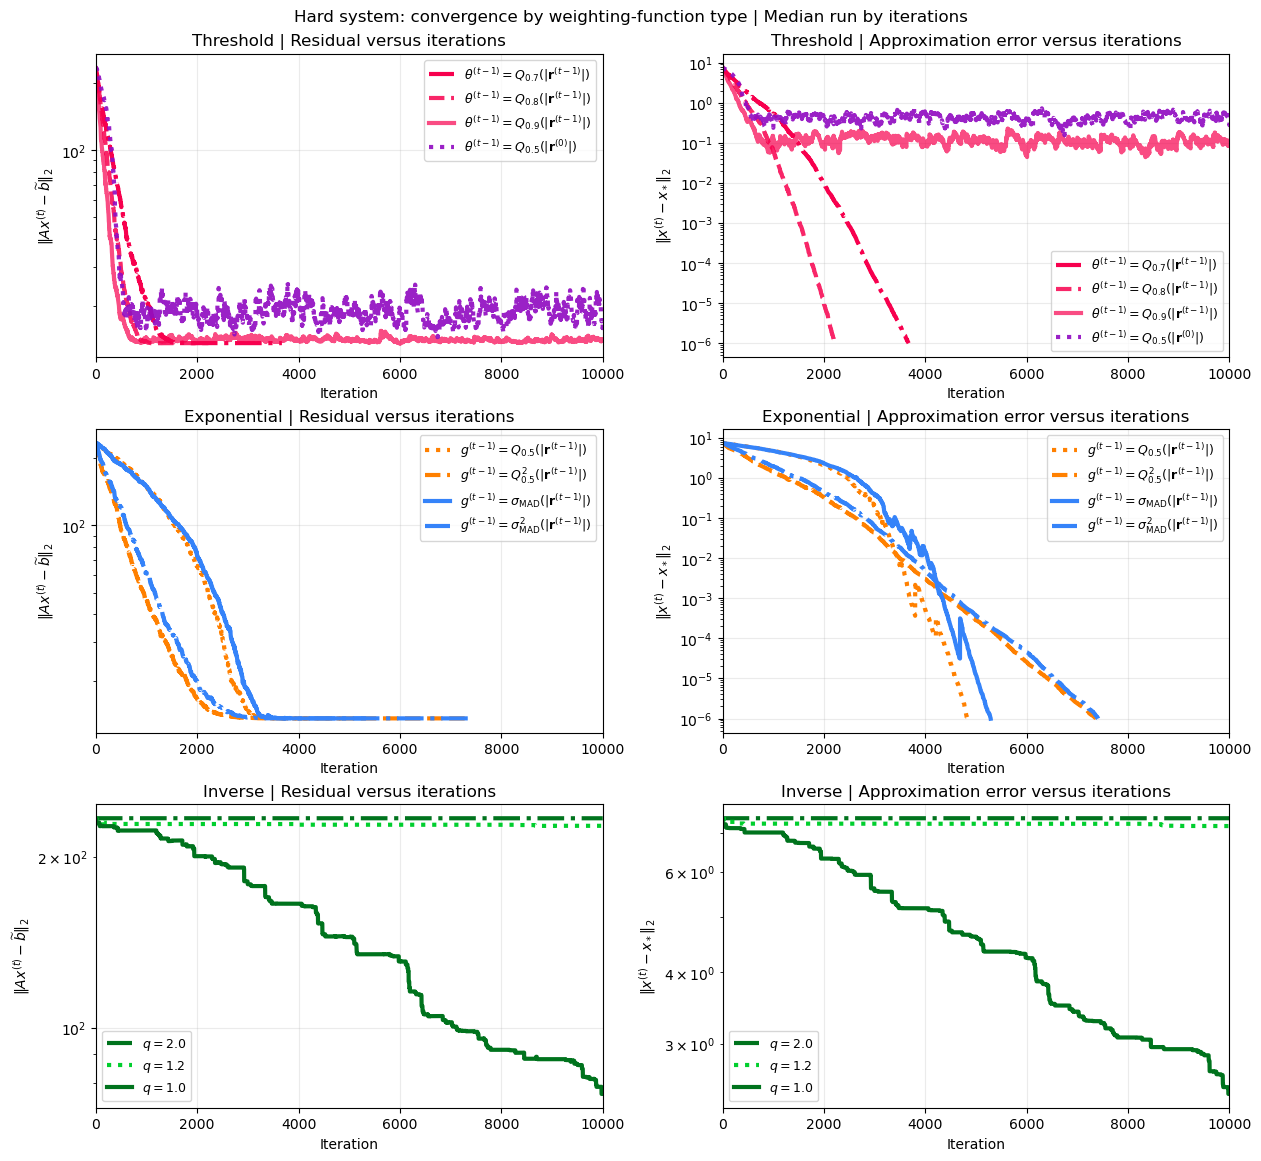

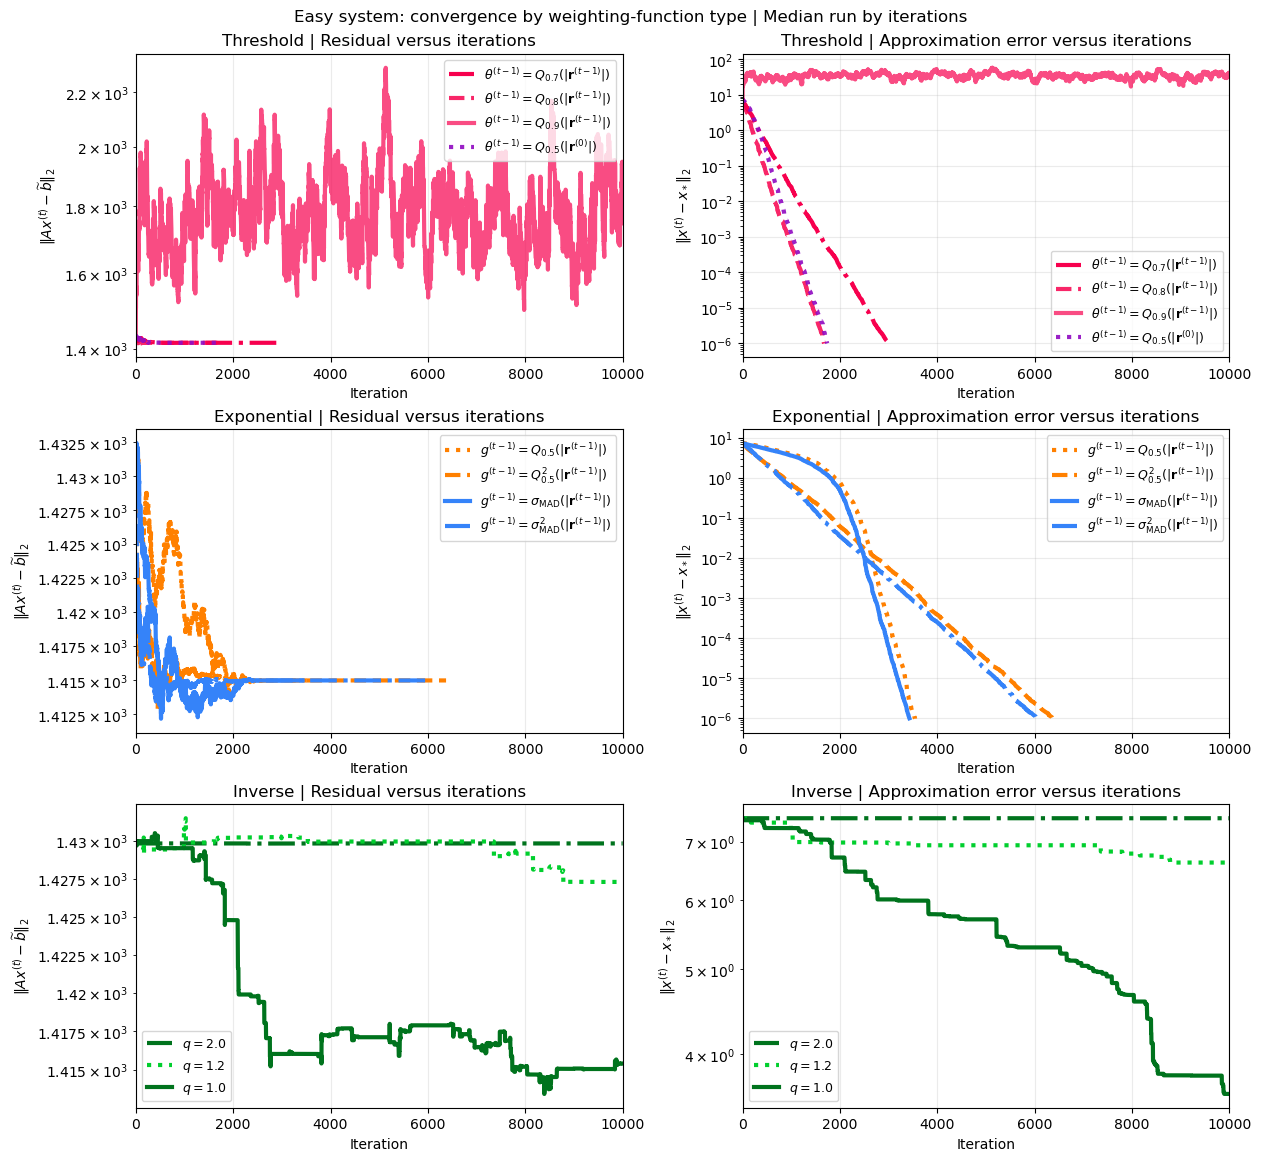

In [11]:
# Use "residual", "approx_error", or "residual_and_approx_error".
comparison_groups = (
    ("Threshold", FUNCTION_THRESHOLD_NAMES),
    ("Exponential", FUNCTION_EXP_NAMES),
    ("Inverse", FUNCTION_INV_NAMES),
)

if plot_what not in ("residual", "approx_error", "residual_and_approx_error"):
    raise ValueError(
        "plot_what must be 'residual', 'approx_error', or "
        "'residual_and_approx_error'."
    )

combined_figures = {}
combined_axes_by_system = {}
combined_median_runs_by_system = {}
for system_name, system_label in (("hard", "Hard system"), ("easy", "Easy system")):
    if plot_what == "residual_and_approx_error":
        combined_fig, combined_axes = plt.subplots(
            3, 2, figsize=(12.5, 11.5), sharex="row", squeeze=False,
            layout="constrained",
        )
    else:
        combined_fig, combined_axes = plt.subplots(
            1, 3, figsize=(17, 4.4), squeeze=False, layout="constrained",
        )

    system_median_runs = {}
    for group_index, (group_name, function_names) in enumerate(comparison_groups):
        group_axes = (
            combined_axes[group_index, :]
            if plot_what == "residual_and_approx_error"
            else combined_axes[0, group_index]
        )
        _, plotted_axes, group_median_runs = plot_convergence_inonefig(
            results_by_system[system_name],
            function_names=function_names,
            plot_what=plot_what,
            x_axis_use_same_scale=x_axis_use_same_scale,
            axes=group_axes,
            median_by=MEDIAN_BY,
            show_clean_residual=False,
            log_scale=True,
            show=False,
        )
        system_median_runs.update(group_median_runs)
        for ax in plotted_axes:
            ax.set_title(f"{group_name} | {ax.get_title()}")

    combined_fig.suptitle(
        f"{system_label}: convergence by weighting-function type | "
        f"Median run by {MEDIAN_BY}",
        fontsize=12,
    )
    combined_figures[system_name] = combined_fig
    combined_axes_by_system[system_name] = combined_axes
    combined_median_runs_by_system[system_name] = system_median_runs
    plt.show()


-------
## Plot CONVERGENCE for every weighting function separately

#### Helpful for debugging.
#### Disable this section if do not need the long detailed plotting results.

In [12]:
# # Plot every hard-system method first, then every easy-system method.
# for system_name, system_results in (("Hard", hard_results), ("Easy", easy_results)):
#     print(f"\n{'=' * 20} {system_name} system {'=' * 20}")
#     for function_name in FUNCTION_NAMES:
#         print("=" * 15, function_name, "=" * 15)
#         fig, axes, median_run = plot_convergence(
#             system_results,
#             function_name,
#             median_by=MEDIAN_BY,
#             show_clean_residual=False,
#             plot_weights_snapshot=True,
#             plot_hist=True,
#         )
#         print("\n")


-------
## Paper-ready Figures ( two representatives)


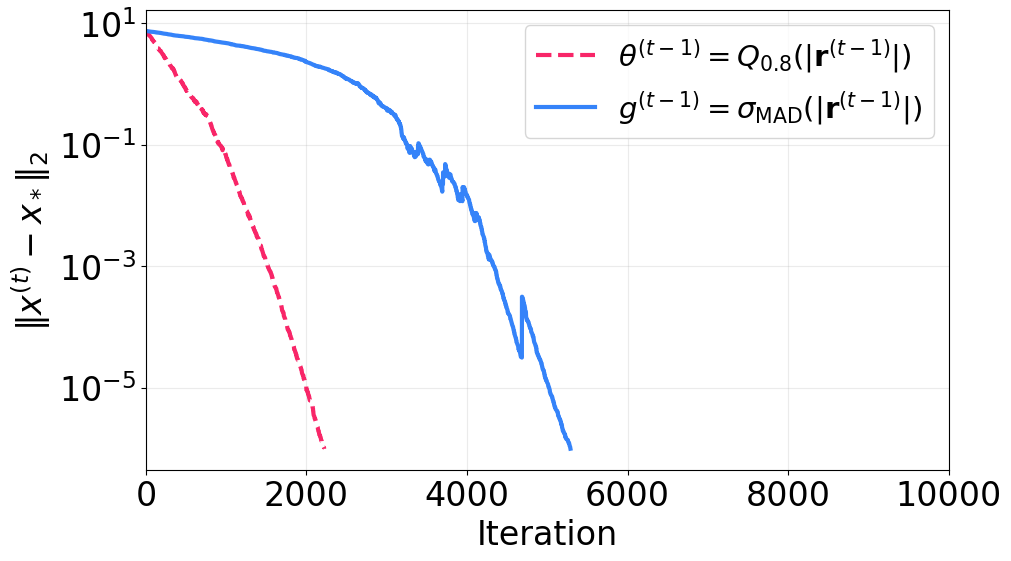

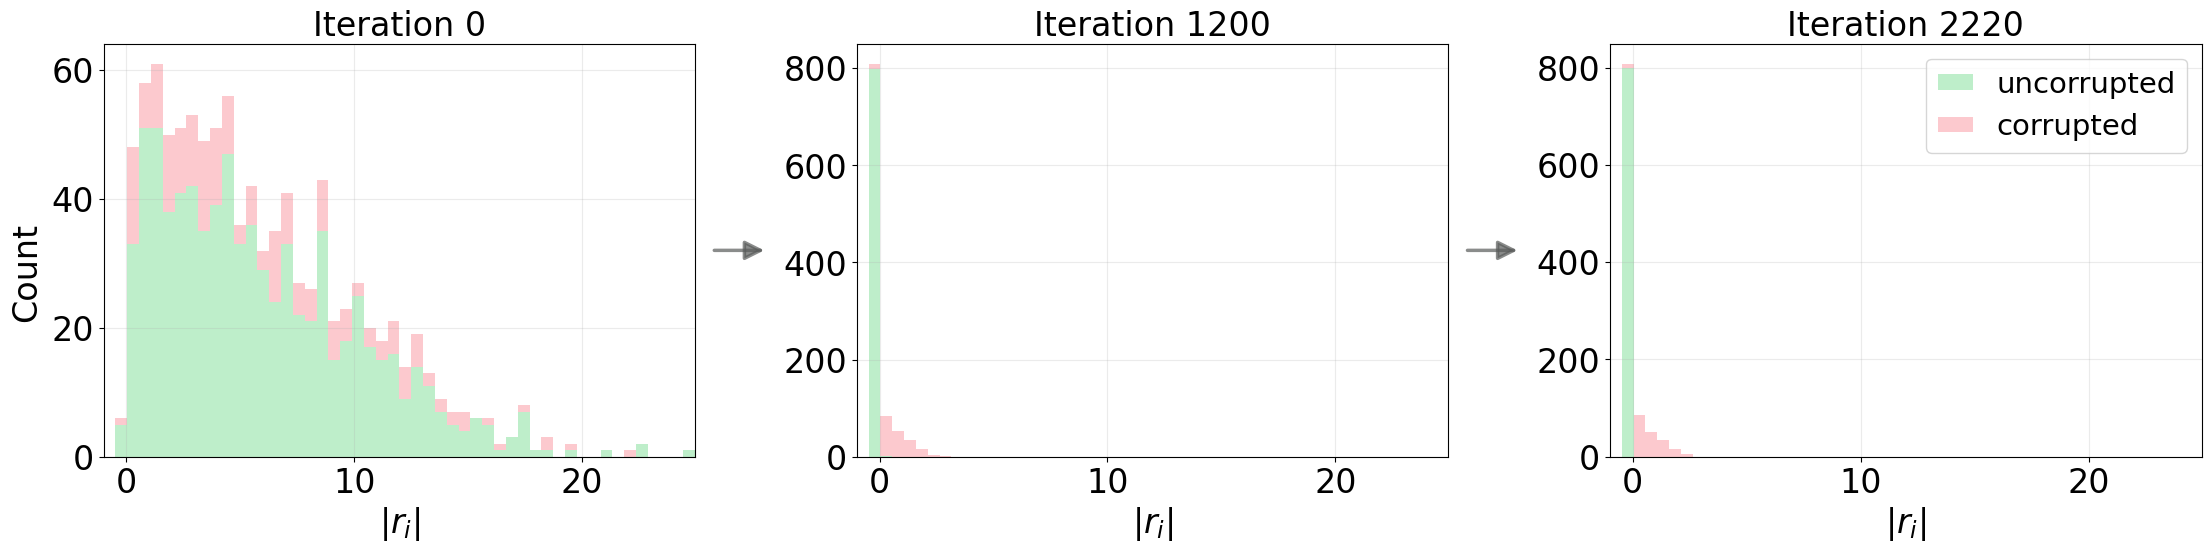

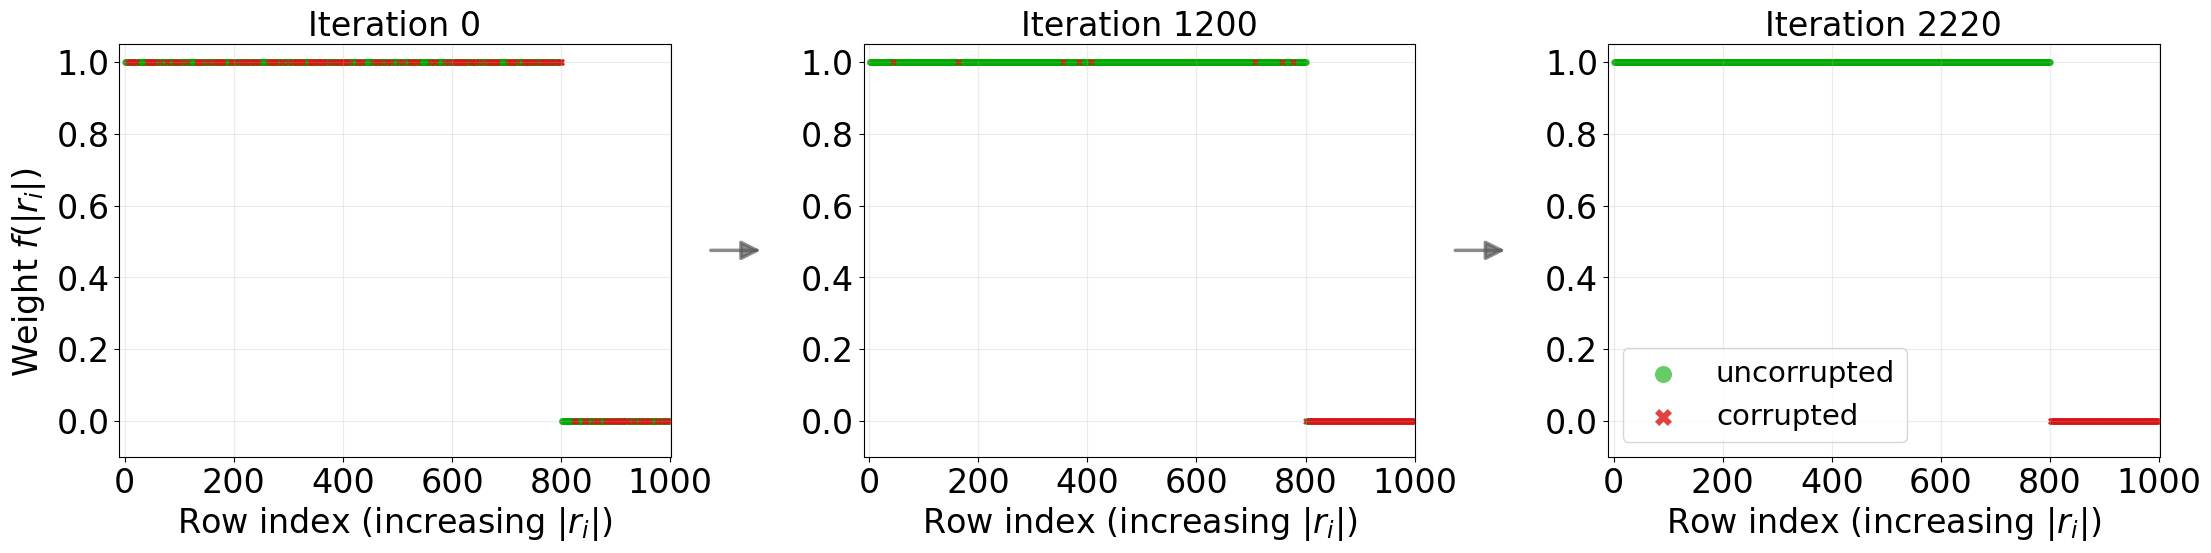

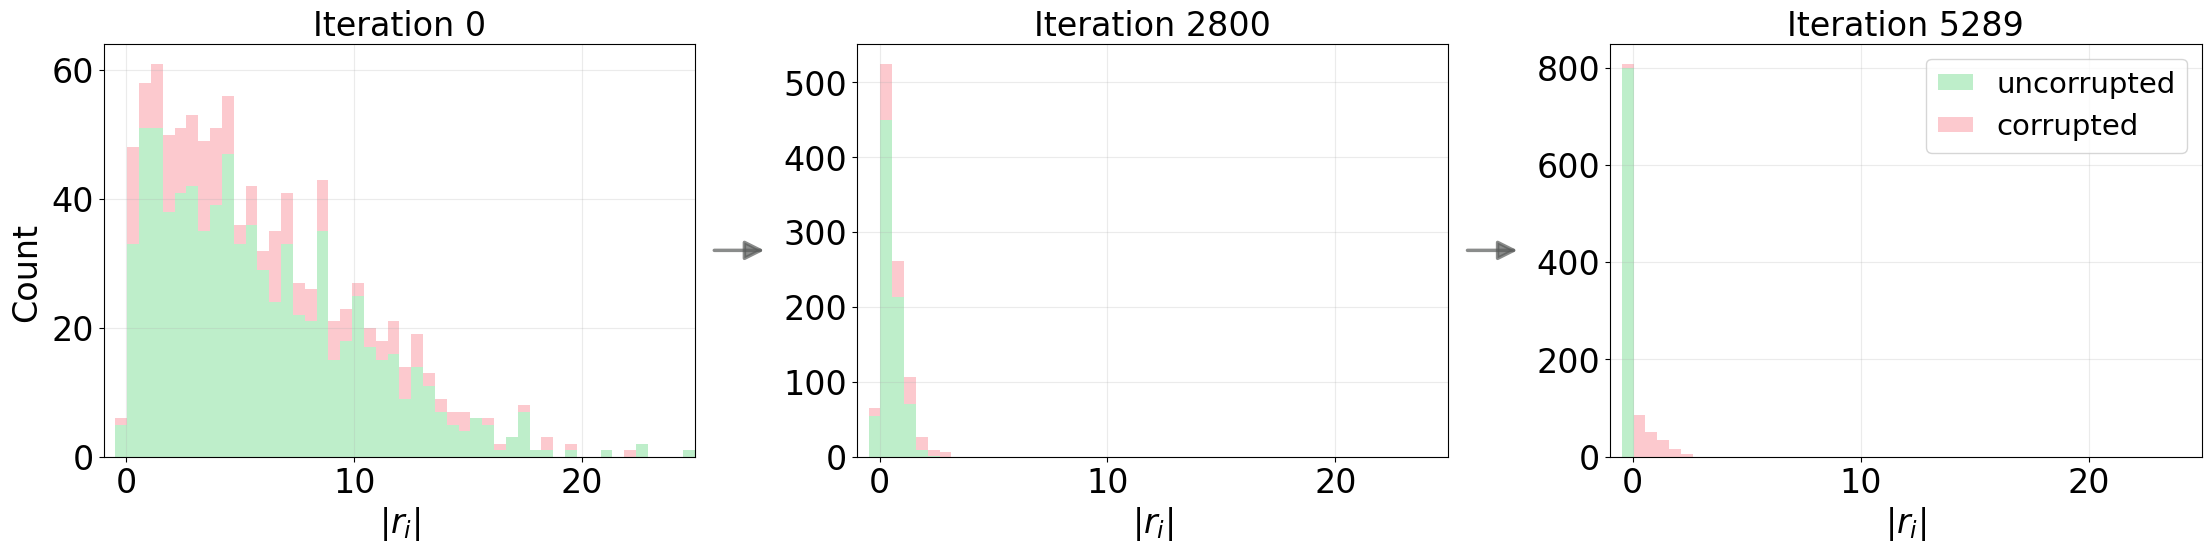

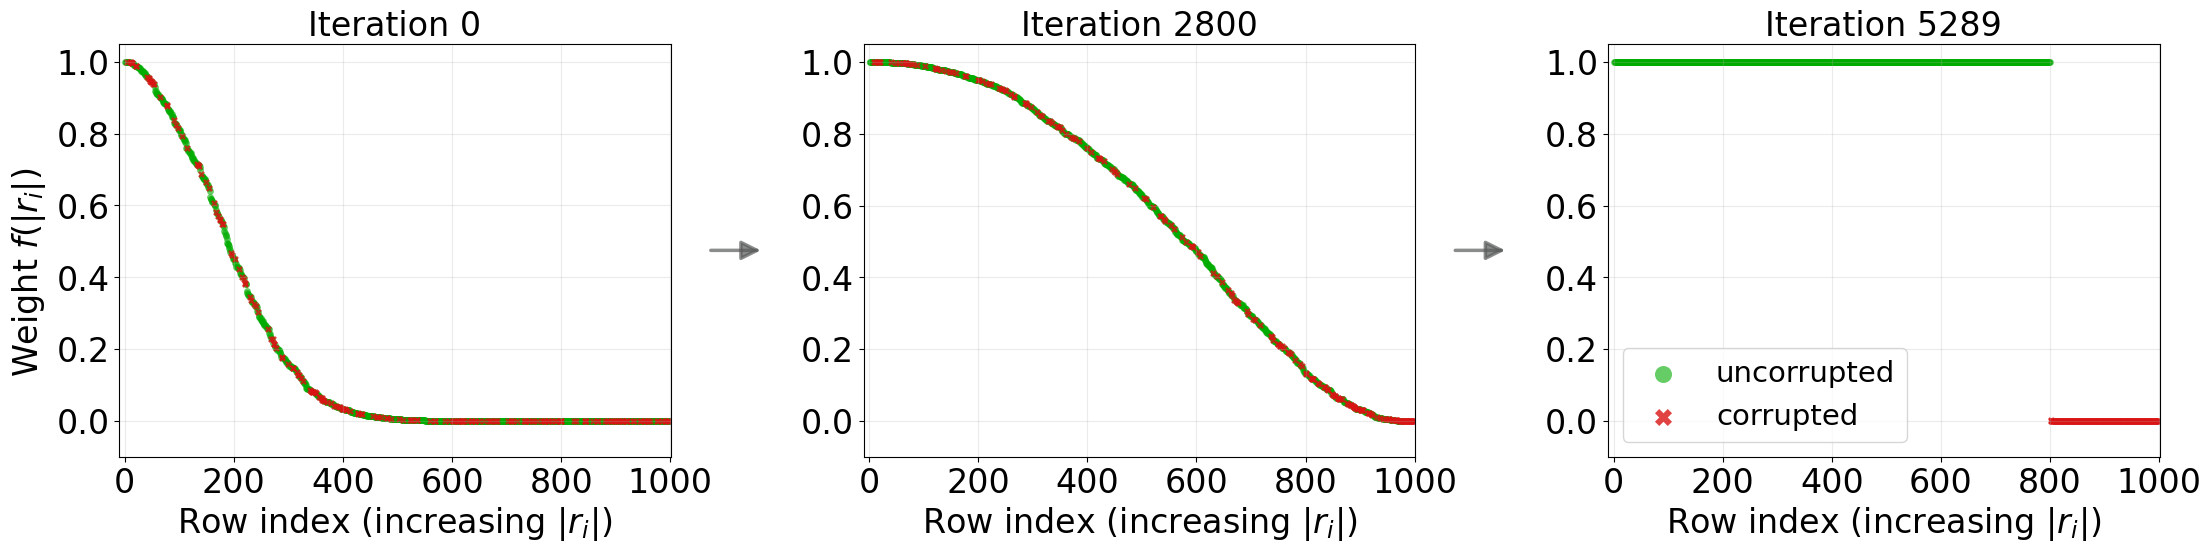

In [13]:
# Reuse the hard-system median runs and three stored snapshots; no experiments rerun.
paper_ready_function_names = ("QRK(q=0.8)", "exp_sig_unsq")
paper_ready_convergence_size = (10.0, 5.5)  # Width and height in inches.
paper_ready_snapshot_size = (22.0, 5.5)
paper_ready_snapshot_spacing = 0.12  # Increase to leave more room between panels.
# Arrow controls: increase these values for longer arrows, larger heads, or thicker shafts.
paper_ready_arrow_length_points = 36.0  # Maximum arrow length in points (72 points = 1 inch).
paper_ready_arrow_head_size = 1.2 * FIGURE_FONT_SIZE  # Arrowhead size; increase for a bigger head.
paper_ready_arrow_linewidth = 2.5  # Shaft/outline thickness in points; increase for a bolder arrow.
paper_ready_arrow_gap_fraction = 0.8  # Fraction of the free gap used (0 < value < 1).
# Length is capped by the free gap to avoid tick labels; increase snapshot_spacing above
# if raising arrow_length_points no longer makes the arrows longer.
# Legend controls for this section: edit these lines to adjust their appearance.
paper_ready_legend_font_size = FIGURE_FONT_SIZE - 3  # Font size of ALL five legends.
paper_ready_snapshot_legend_labels = ("uncorrupted", "corrupted")  # Snapshot labels only.
paper_ready_hist_legend_handlelength = 1.2  # Histogram swatch width; smaller = narrower.
paper_ready_hist_legend_handleheight = 0.45  # Histogram swatch height; smaller = thinner.
# Swatch width/height above are in multiples of the legend font size.
paper_ready_weight_legend_markerscale = 2.5  # Legend marker diameter multiplier; larger = bigger.
# This multiplier changes only the legend; MARKER_SIZE still controls plotted scatter area (pt^2).
# Histogram bars and swatches use HISTIGRAM_UNCORRUPTED_COLOR / HISTIGRAM_CORRUPTED_COLOR
# through _plot_residual_histograms, including the transparency in those hex colors.
# Other text keeps FIGURE_FONT_SIZE.

from matplotlib.patches import ConnectionPatch


def _style_paper_ready_axis(ax):
    ax.xaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.yaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.title.set_fontsize(FIGURE_FONT_SIZE)
    ax.tick_params(axis="both", which="both", labelsize=FIGURE_FONT_SIZE)
    ax.xaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE)
    ax.yaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE)


def _add_paper_snapshot_arrows(fig, axes):
    """Draw a right-pointing arrow in each gap, clear of tick labels."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    arrows = []
    for left_ax, right_ax in zip(axes[:-1], axes[1:]):
        left_box = left_ax.get_window_extent(renderer)
        right_box = right_ax.get_window_extent(renderer)
        # Stop before the next panel's tick labels, not just its plotting border.
        gap_left = left_box.x1
        gap_right = right_ax.get_tightbbox(renderer).x0
        arrow_length = min(
            paper_ready_arrow_length_points * fig.dpi / 72,
            paper_ready_arrow_gap_fraction * (gap_right - gap_left),
        )
        if arrow_length <= 0:
            raise ValueError("Increase paper_ready_snapshot_spacing to make room for arrows.")
        center = (gap_left + gap_right) / 2
        start_x = (center - arrow_length / 2 - left_box.x0) / left_box.width
        end_x = (center + arrow_length / 2 - right_box.x0) / right_box.width
        arrow = ConnectionPatch(
            xyA=(start_x, 0.5), coordsA=left_ax.transAxes,
            xyB=(end_x, 0.5), coordsB=right_ax.transAxes,
            arrowstyle="-|>", mutation_scale=paper_ready_arrow_head_size,
            linewidth=paper_ready_arrow_linewidth, color="#595B5AB3",
            shrinkA=0, shrinkB=0, clip_on=False,
        )
        # The arrow follows the axes on redraw/export without changing their layout.
        arrow.set_in_layout(False)
        fig.add_artist(arrow)
        arrows.append(arrow)
    return arrows


def _format_paper_snapshot_figure(fig, axes, run, *, weights):
    axes = np.asarray(axes, dtype=object).ravel()
    fig.set_size_inches(*paper_ready_snapshot_size)
    fig.get_layout_engine().set(wspace=paper_ready_snapshot_spacing)
    fig.suptitle("", fontsize=FIGURE_FONT_SIZE)  # Hide the main title.
    for ax in axes:
        ax.set_ylabel("")  # One shared y-axis label is added below.
        if weights:
            ax.set_xlabel(r"Row index (increasing $|r_i|$)")
            ax.set_xticks([0, 200, 400, 600, 800, 1000])  # Tick positions for every weight snapshot.
            for collection in ax.collections:
                collection.set_sizes([MARKER_SIZE])  # Scatter marker area in points squared.
        _style_paper_ready_axis(ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    fig.supylabel(r"Weight $f(|r_i|)$" if weights else "Count", fontsize=FIGURE_FONT_SIZE)
    handles, _ = axes[-1].get_legend_handles_labels()
    # Keep only the two row categories: no function/formula title in snapshot legends.
    legend_options = (
        {"markerscale": paper_ready_weight_legend_markerscale}
        if weights else {
            "handlelength": paper_ready_hist_legend_handlelength,
            "handleheight": paper_ready_hist_legend_handleheight,
        }
    )
    # One shared legend: upper right for histograms, lower left for weights.
    axes[-1].legend(
        handles, paper_ready_snapshot_legend_labels,
        loc="lower left" if weights else "upper right",
        fontsize=paper_ready_legend_font_size, **legend_options,
    )
    arrows = _add_paper_snapshot_arrows(fig, axes)
    return axes, arrows


paper_ready_figures = {}
paper_ready_axes = {}
paper_ready_arrows = {}
paper_ready_snapshot_iterations = {}
with plt.rc_context({
    "font.size": FIGURE_FONT_SIZE,
    "axes.titlesize": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": paper_ready_legend_font_size,
    "legend.title_fontsize": paper_ready_legend_font_size,
    "xtick.labelsize": FIGURE_FONT_SIZE,
    "ytick.labelsize": FIGURE_FONT_SIZE,
    "figure.labelsize": FIGURE_FONT_SIZE,
}):
    comparison_fig, comparison_ax = plt.subplots(
        figsize=paper_ready_convergence_size, layout="constrained",
    )
    _, _, paper_ready_median_runs = plot_convergence_inonefig(
        hard_results, function_names=paper_ready_function_names,
        plot_what="approx_error", x_axis_use_same_scale=x_axis_use_same_scale,
        axes=comparison_ax, median_by=MEDIAN_BY, log_scale=True, show=False,
    )
    comparison_ax.set_title("")
    _style_paper_ready_axis(comparison_ax)
    comparison_ax.legend(loc="upper right", fontsize=paper_ready_legend_font_size)
    paper_ready_figures["convergence"] = comparison_fig
    paper_ready_axes["convergence"] = comparison_ax

    for function_name, prefix in (("QRK(q=0.8)", "QRK"), ("exp_sig_unsq", "exp_sig_unsq")):
        run = paper_ready_median_runs[function_name]
        selected_snapshots, _ = _select_residual_snapshots(run, max_snapshots=3)
        paper_ready_snapshot_iterations[function_name] = [iteration for iteration, _ in selected_snapshots]
        # Both existing helpers use identical initial/middle/final snapshot selection.
        for weights, suffix in ((False, "histogram"), (True, "weights")):
            plot_snapshots = _plot_weight_snapshots if weights else _plot_residual_histograms
            fig, axes = plot_snapshots(run, max_snapshots=3, median_by=MEDIAN_BY)
            axes, arrows = _format_paper_snapshot_figure(fig, axes, run, weights=weights)
            figure_name = f"{prefix}_{suffix}"
            paper_ready_figures[figure_name] = fig
            paper_ready_axes[figure_name] = axes
            paper_ready_arrows[figure_name] = arrows
    plt.show()


-------
## Plot DISTRIBUTION and CONVERGENCE of each type


In [14]:
# Four separate figures per system: the shared initial distribution, followed
# by one approximation-error figure for each weighting-function type.
# This line controls the legend font size for ALL four figures in this section.
distribution_legend_font_size = FIGURE_FONT_SIZE - 4

distribution_convergence_groups = (
    ("Threshold", FUNCTION_THRESHOLD_NAMES),
    ("Exponential", FUNCTION_EXP_NAMES),
    ("Inverse", FUNCTION_INV_NAMES),
)


from matplotlib.offsetbox import VPacker
from matplotlib.patches import FancyBboxPatch


class _DistributionLegendBox(VPacker):
    """Keep the legend's outer panel dimensions fixed in physical units."""
    def __init__(self, original_box, size_points):
        super().__init__(pad=original_box.pad, sep=original_box.sep,
                         align='left', children=original_box.get_children())
        self.size_points = size_points
        self.set_offset(original_box._offset)

    def _get_bbox_and_child_offsets(self, renderer):
        self.width, self.height = (
            renderer.points_to_pixels(value - 2 * self.pad)
            for value in self.size_points
        )
        return super()._get_bbox_and_child_offsets(renderer)


def _match_distribution_legend_panels(axes):
    legends = [ax.get_legend() for ax in axes]
    sizes = []
    for legend in legends:
        fig = legend.get_figure()
        fig.canvas.draw()
        sizes.append(np.array(legend.get_window_extent().size) * 72 / fig.dpi)
    size_points = np.max(sizes, axis=0) #+ 2
    for legend in legends:
        box = _DistributionLegendBox(legend._legend_box, size_points)
        box.set_figure(legend.get_figure())
        box.axes = legend.axes
        legend._legend_box = box
    return size_points


def _style_distribution_convergence_axis(ax):
    """Hide the title and apply this section's fonts and external legend."""
    ax.set_title("")
    ax.xaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.yaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.tick_params(axis="both", which="both", labelsize=FIGURE_FONT_SIZE - 2)
    ax.xaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    ax.yaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    ax.legend(
        loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0,
        fontsize=distribution_legend_font_size, title_fontsize=distribution_legend_font_size,
        handlelength=1.5,   # Length of the line sample; smaller = shorter.
        handletextpad=0.25,  # Gap between the line sample and its label.
    )


def _add_inverse_convergence_inset(ax, selected_runs):
    """Zoom the inverse curves on a linear y-axis without rescaling the main plot."""
    # Rounded inset appearance: edit these values to customize the frame.
    inset_border_color = "#737171"  # Edge color: a hex string or name, e.g. "black".
    inset_border_width = 1.5        # Edge thickness in points.
    inset_border_padding = 0.02    # Extra space outside the plotting area (axes units).
    inset_corner_radius = 0.08     # Larger values make the corners more rounded.
    inset_background_color = "white"  # Fill color inside the rounded box.

    # Position: (left, bottom, width, height), as fractions of the main axes.
    # Increase left/bottom to move right/up; increase width/height to enlarge.
    inset = ax.inset_axes((0.47, 0.225, 0.47, 0.42), facecolor=inset_background_color)
    # Replace the rectangular frame/background; keep the ticks and labels.
    for spine in inset.spines.values():
        spine.set_visible(False)
    inset.patch.set_visible(False)
    rounded_border = FancyBboxPatch(
        (0, 0), 1, 1, transform=inset.transAxes,
        boxstyle=f"round,pad={inset_border_padding},rounding_size={inset_corner_radius}",
        edgecolor=inset_border_color, linewidth=inset_border_width,
        facecolor=inset_background_color,
        clip_on=False, zorder=-1,  # Show the padded border behind curves and grid.
    )
    inset.add_patch(rounded_border)
    for name, run in selected_runs.items():
        inset.plot(
            run.iterations, run.approximation_error,
            color=function_color_map[name], linestyle=function_line_style_map[name],
            linewidth=LINEWIDTH, alpha=function_alpha_map.get(name),
        )

    # Fit the zoom to the actual inverse errors, with a small margin on each side.
    errors = np.concatenate([run.approximation_error for run in selected_runs.values()])
    minimum, maximum = float(errors.min()), float(errors.max())
    padding = max(0.08 * (maximum - minimum), 0.01 * maximum, 1e-12)
    inset.set_xlim(4000, 10000) #(ax.get_xlim())
    inset.set_yscale("linear")
    # inset.set_ylim(3.5, 7.9)  
    inset.set_ylim(max(np.finfo(float).tiny, minimum - padding), maximum + padding)
    inset.set_ylabel(ax.get_ylabel() + " (linear)", fontsize=FIGURE_FONT_SIZE - 4.5)
    inset.tick_params(axis="both", which="both", labelsize=FIGURE_FONT_SIZE - 5.5)
    inset.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
    inset.yaxis.set_major_locator(MaxNLocator(nbins=4))
    inset.ticklabel_format(axis="both", style="plain", useOffset=False)
    inset.xaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    inset.yaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    inset.grid(True, alpha=0.15)
    # These settings style the connector lines, independently of the inset border.
    zoom_indicator = ax.indicate_inset_zoom(
        inset, edgecolor="0.4", linewidth=1.0, alpha=0.5,
    )
    # Hide only the zoom-region outline; keep the chosen connector lines.
    # A transparent edge makes Matplotlib draw the connectors separately.
    # Change "none" to "0.4" to show the zoom-region rectangle again.
    zoom_indicator.rectangle.set_edgecolor("none")
    return inset


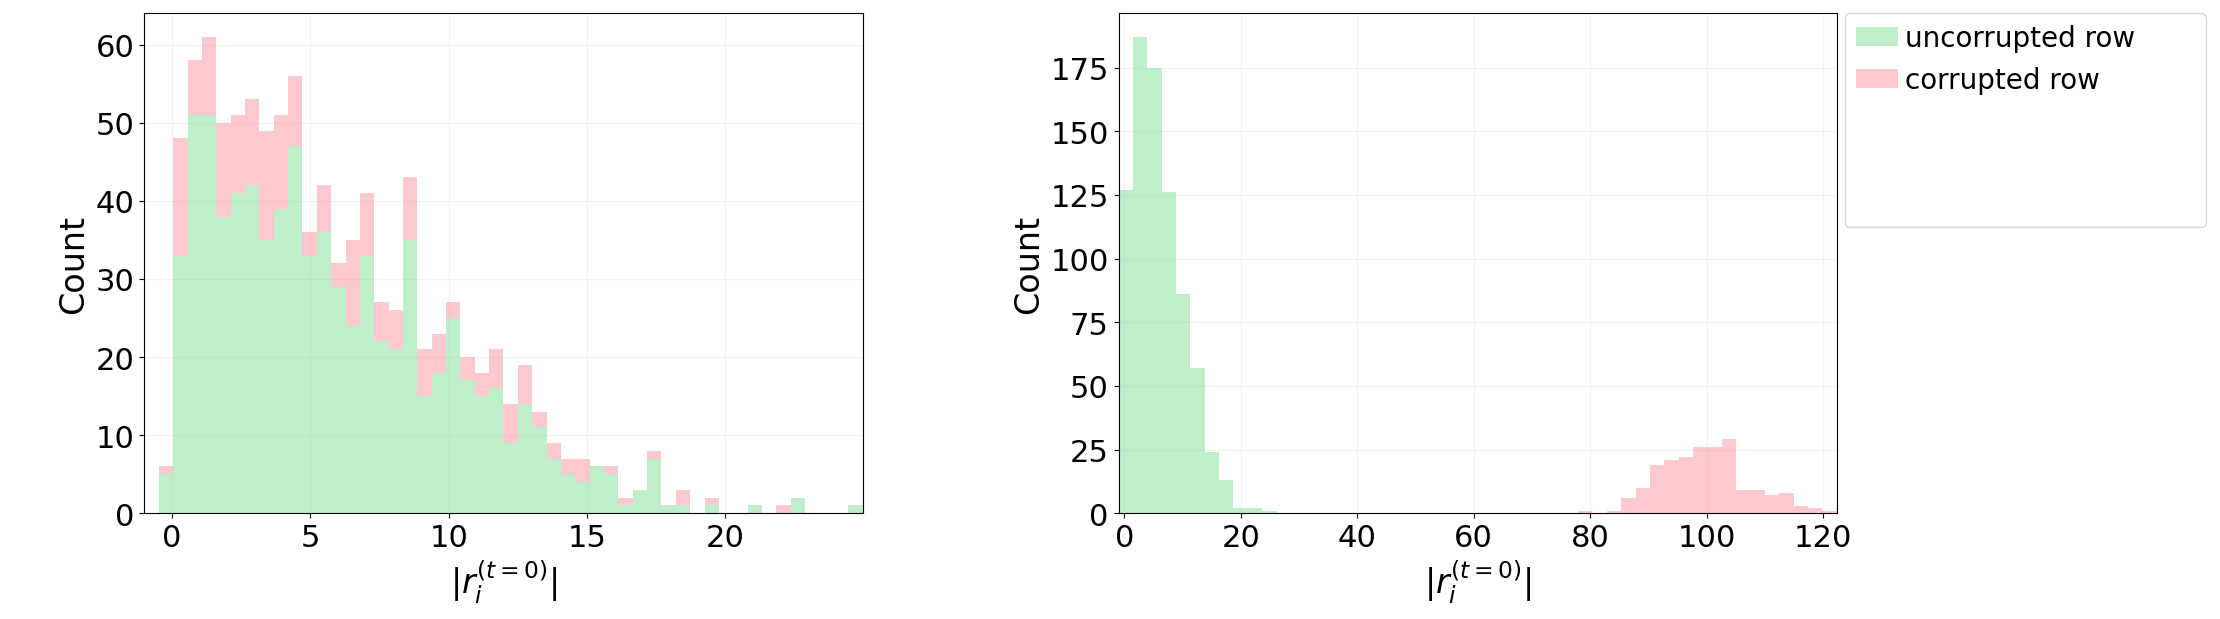

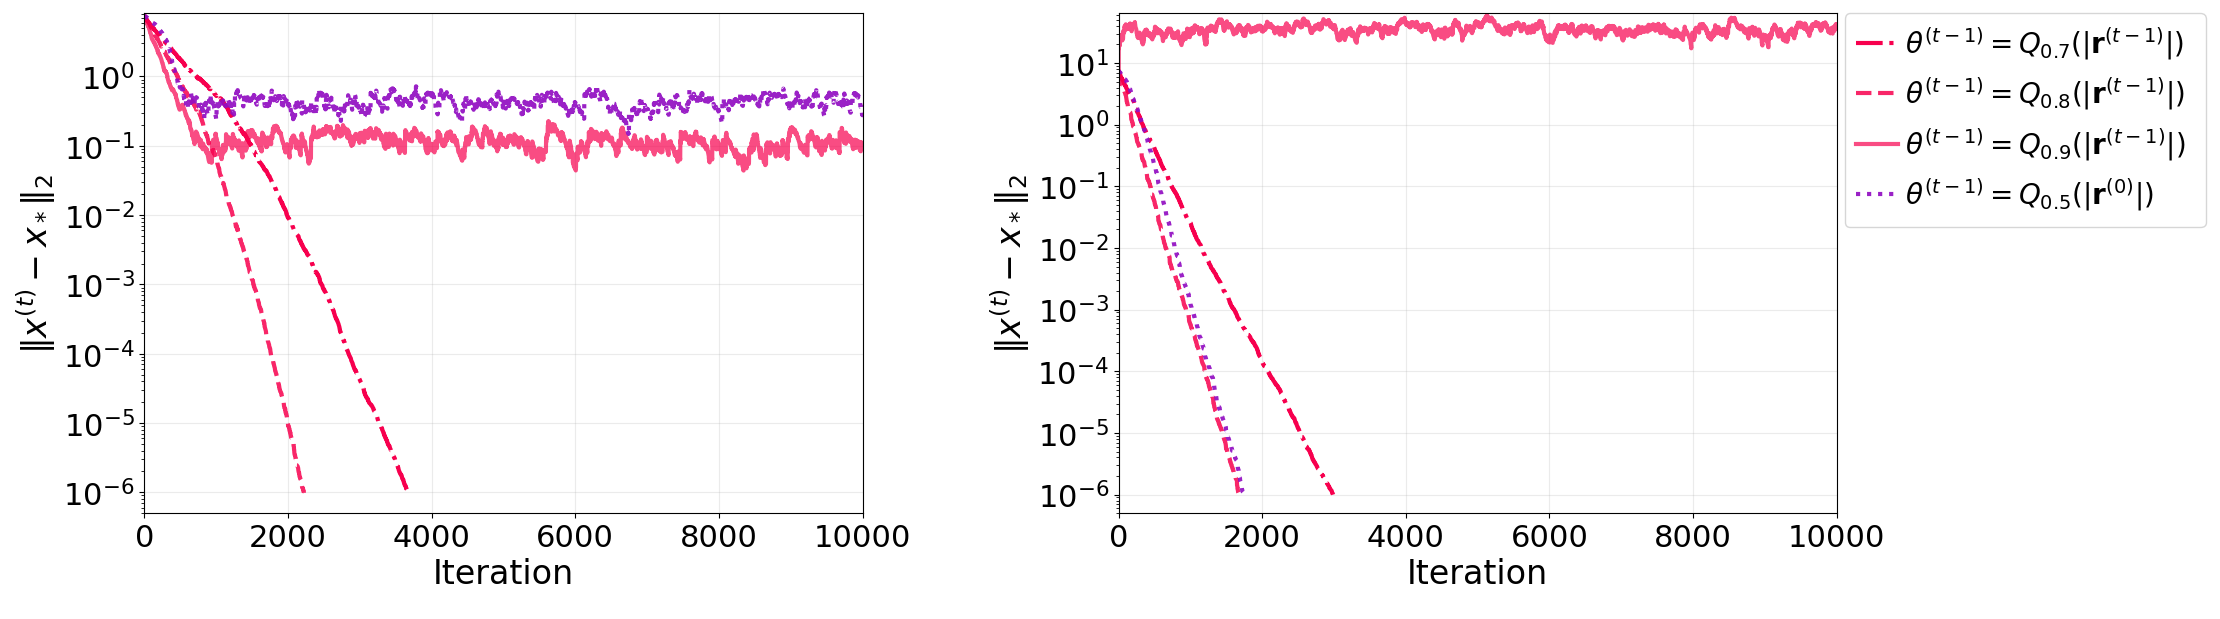

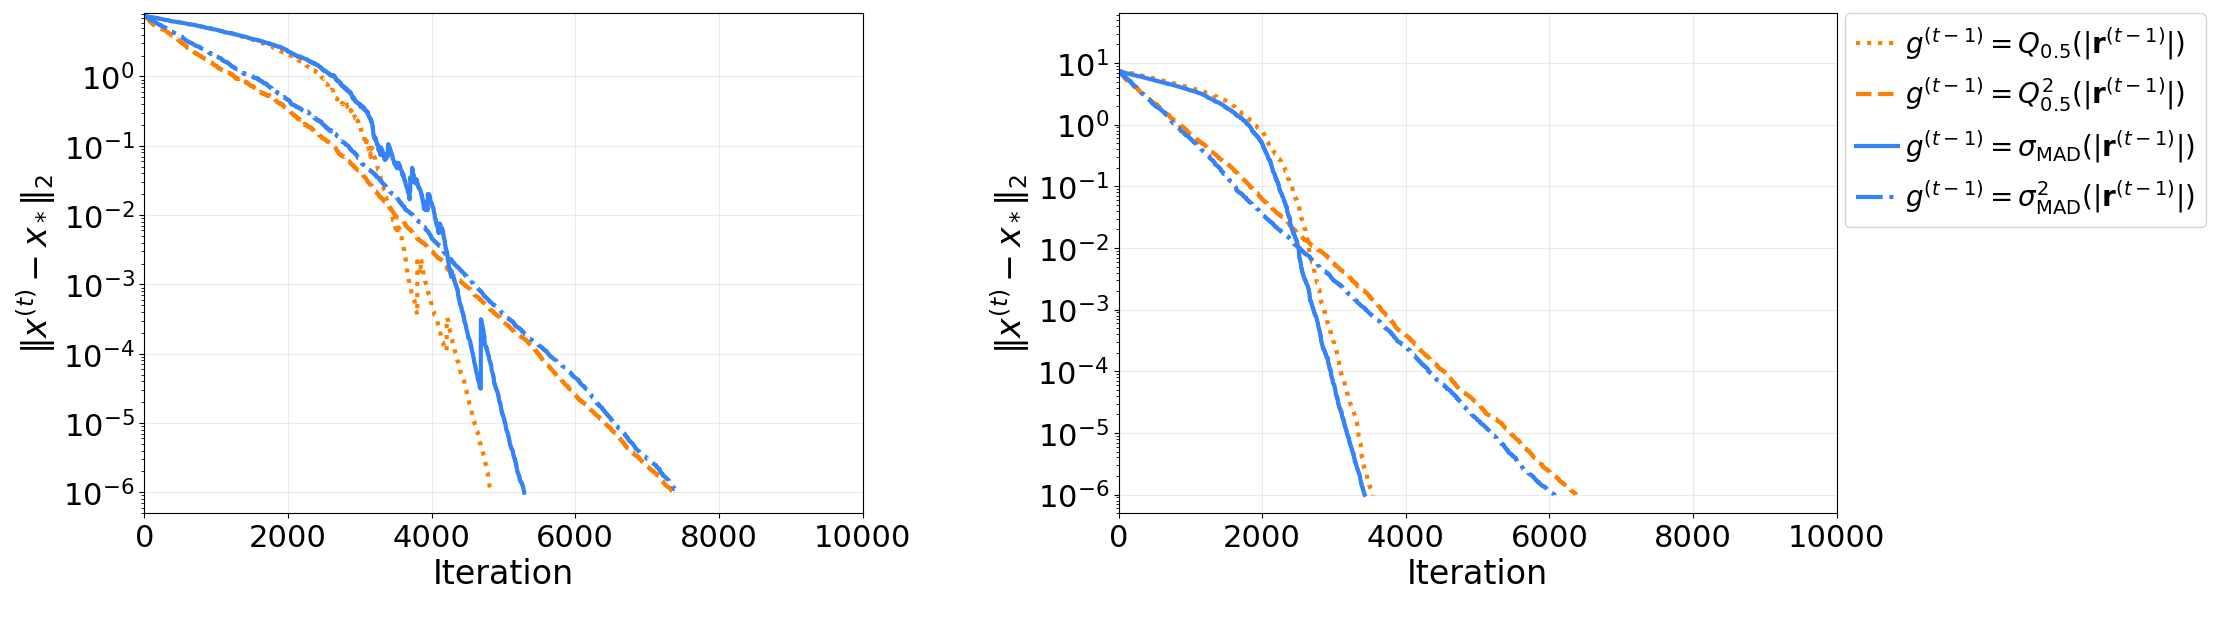

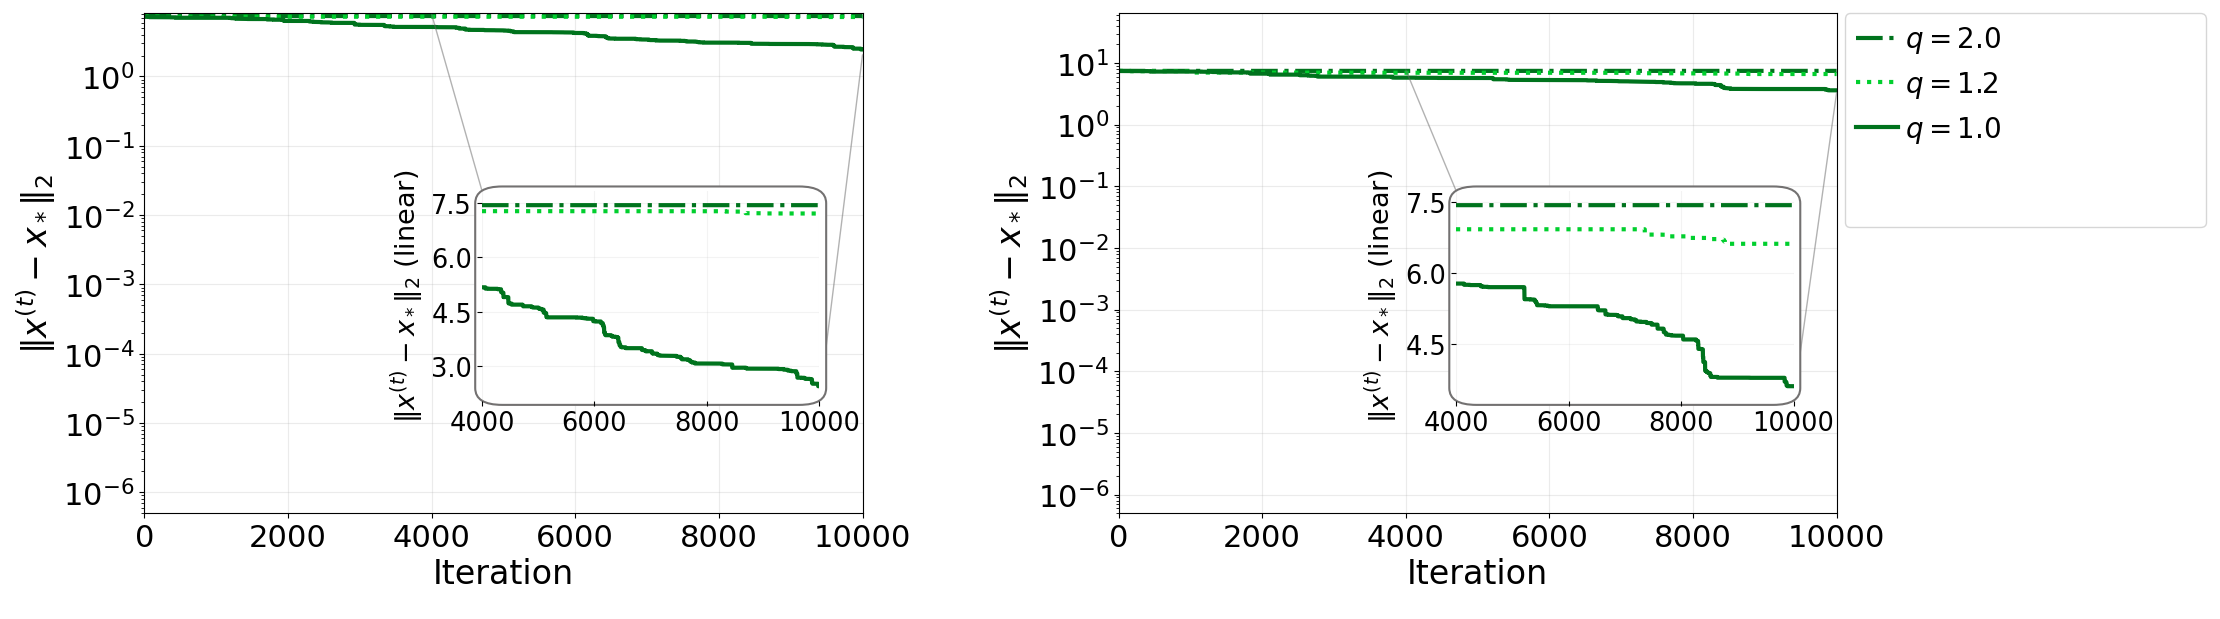

In [15]:
# Four figures: hard system on the left, easy system on the right.
# This section reuses the experiments and inset helper from the preceding section.
paired_figure_size = (22.0, 6.0)  # Overall (width, height), in inches.
# Increase this to widen the gap; the final panel positions are matched across all four figures.
paired_column_spacing = 0.07
paired_legend_font_size = distribution_legend_font_size
paired_legend_handlelength = 1.5  # Length of each legend line sample.
paired_legend_handletextpad = 0.25  # Gap between each line sample and its label.
paired_legend_gap_points = 6.0  # Gap from the right plot to its shared legend; smaller = closer.
paired_right_margin_points = 3.0  # Small gap from the legend to the figure edge.

paired_systems = (
    ("hard", hard_system, hard_results),
    ("easy", easy_system, easy_results),
)
paired_function_groups = (
    ("Threshold", FUNCTION_THRESHOLD_NAMES),
    ("Exponential", FUNCTION_EXP_NAMES),
    ("Inverse", FUNCTION_INV_NAMES),
)


def _style_paired_distribution_axis(ax):
    """Apply the current fonts without titles or panel subcaptions."""
    ax.set_title("")
    ax.xaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.yaxis.label.set_fontsize(FIGURE_FONT_SIZE)
    ax.tick_params(axis="both", which="both", labelsize=FIGURE_FONT_SIZE - 2)
    ax.xaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    ax.yaxis.get_offset_text().set_fontsize(FIGURE_FONT_SIZE - 2)
    # Each figure gets one shared legend, so remove the plotting helper's legend.
    if ax.get_legend() is not None:
        ax.get_legend().remove()


def _align_paired_distribution_panels(
    figures, axes_by_figure, legends_by_figure, *, legend_gap_points, right_margin_points,
):
    """Match panel geometry and fill the width left after reserving the legend."""
    positions_by_column = [[], []]
    legend_widths_points = []
    for figure_name, fig in figures.items():
        # Measure after the shared legend boxes have received their final sizes.
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        legend_widths_points.append(
            legends_by_figure[figure_name].get_window_extent(renderer).width * 72 / fig.dpi
        )
        for column, system_name in enumerate(("hard", "easy")):
            ax = axes_by_figure[figure_name][system_name]
            positions_by_column[column].append(ax.get_position().frozen())

    # Keep enough room for the largest labels and the requested column spacing.
    left_edges = [max(box.x0 for box in boxes) for boxes in positions_by_column]
    right_edges = [min(box.x1 for box in boxes) for boxes in positions_by_column]
    all_positions = [box for boxes in positions_by_column for box in boxes]
    bottom = max(box.y0 for box in all_positions)
    top = min(box.y1 for box in all_positions)
    fitted_width = min(right - left for left, right in zip(left_edges, right_edges))
    column_gap = left_edges[1] - (left_edges[0] + fitted_width)

    # Reserve only the legend width, its gap, and a small outer margin on the right.
    # Split ALL remaining horizontal space equally between the two plotting panels.
    figure_width_points = next(iter(figures.values())).get_figwidth() * 72
    right_panel_edge = 1 - (
        max(legend_widths_points) + legend_gap_points + right_margin_points
    ) / figure_width_points
    width = (right_panel_edge - left_edges[0] - column_gap) / 2
    if width <= 0 or top <= bottom:
        raise ValueError("Increase paired_figure_size to make room for the labels and legends.")
    shared_positions = (
        (left_edges[0], bottom, width, top - bottom),
        (left_edges[0] + width + column_gap, bottom, width, top - bottom),
    )

    for figure_name, fig in figures.items():
        # Freeze the layout so drawing/export cannot resize each figure separately.
        fig.set_layout_engine("none")
        # Keep the full common canvas when notebook display/export crops to tight bounds.
        fig.patch.set_in_layout(True)
        for system_name, position in zip(("hard", "easy"), shared_positions):
            axes_by_figure[figure_name][system_name].set_position(position)
    return shared_positions


# Preserve the preceding section's shared convergence scale within each system.
paired_distribution_convergence_median_runs_by_system = {}
paired_convergence_y_limits = {}
for system_name, _, system_results in paired_systems:
    selected_runs = {
        name: select_median_run(system_results[name], MEDIAN_BY)
        for _, names in paired_function_groups for name in names
    }
    paired_distribution_convergence_median_runs_by_system[system_name] = selected_runs
    paired_convergence_y_limits[system_name] = (
        5e-7,
        max(1e-6, 1.1 * max(float(np.max(run.approximation_error))
                            for run in selected_runs.values())),
    )

paired_distribution_convergence_figures = {}
paired_distribution_convergence_axes = {}
paired_distribution_convergence_inverse_insets = {}
paired_distribution_convergence_legends = {}
with plt.rc_context({
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": paired_legend_font_size,
    "xtick.labelsize": FIGURE_FONT_SIZE - 2,
    "ytick.labelsize": FIGURE_FONT_SIZE - 2,
}):
    for figure_name, function_names in (("histogram", None), *paired_function_groups):
        fig, axes = plt.subplots(1, 2, figsize=paired_figure_size, layout="constrained")
        fig.get_layout_engine().set(wspace=paired_column_spacing)
        axes_by_system = {}
        for ax, (system_name, current_system, system_results) in zip(axes, paired_systems):
            if figure_name == "histogram":
                initial_magnitudes = np.abs(current_system.A @ current_system.x0 - current_system.b_tilde)
                corrupt_mask = np.asarray(current_system.corrupt_mask, dtype=bool)
                histogram_upper = max(1.0, float(initial_magnitudes.max()))
                histogram_bins = np.linspace(-1.0, histogram_upper, 51)
                ax.hist(
                    [initial_magnitudes[~corrupt_mask], initial_magnitudes[corrupt_mask]],
                    bins=histogram_bins, stacked=True,
                    color=[HISTIGRAM_UNCORRUPTED_COLOR, HISTIGRAM_CORRUPTED_COLOR],
                    label=["uncorrupted row", "corrupted row"], linewidth=LINEWIDTH,
                )
                ax.set(xlabel=r"$|r_i^{(t=0)}|$", ylabel="Count", xlim=(-1.0, histogram_upper))
                ax.ticklabel_format(useOffset=False, axis="y")
                ax.grid(True, alpha=0.15)
            else:
                _, _, group_selected_runs = plot_convergence_inonefig(
                    system_results,
                    function_names=function_names,
                    plot_what="approx_error",
                    x_axis_use_same_scale=x_axis_use_same_scale,
                    axes=ax, median_by=MEDIAN_BY, log_scale=True, show=False,
                )
                ax.set_ylim(*paired_convergence_y_limits[system_name])
                if figure_name == "Inverse":
                    # Reuse the rounded insets, zoom limits, fonts, and connectors.
                    paired_distribution_convergence_inverse_insets[system_name] = (
                        _add_inverse_convergence_inset(ax, group_selected_runs)
                    )
            _style_paired_distribution_axis(ax)
            axes_by_system[system_name] = ax

        # Both panels have identical labels; take one set from the left panel.
        handles, labels = axes[0].get_legend_handles_labels()
        shared_legend = fig.legend(
            handles, labels,
            loc="outside right upper",  # Outside both panels, at the upper right.
            fontsize=paired_legend_font_size,
            handlelength=paired_legend_handlelength,
            handletextpad=paired_legend_handletextpad,
        )
        paired_distribution_convergence_figures[figure_name] = fig
        paired_distribution_convergence_axes[figure_name] = axes_by_system
        paired_distribution_convergence_legends[figure_name] = shared_legend

    # Keep the four shared legend boxes the same size, as in the preceding section.
    legends = list(paired_distribution_convergence_legends.values())
    legend_sizes = []
    for legend in legends:
        fig = legend.get_figure()
        fig.canvas.draw()
        legend_sizes.append(np.array(legend.get_window_extent().size) * 72 / fig.dpi)
    # Add np.array([extra_width, extra_height]) here for more space, in points.
    paired_legend_size_points = np.max(legend_sizes, axis=0)
    for legend in legends:
        box = _DistributionLegendBox(legend._legend_box, paired_legend_size_points)
        box.set_figure(legend.get_figure())
        box.axes = legend.axes
        legend._legend_box = box
    # Align plotting boxes as well as legend boxes across all four figures.
    # Reserve the legend space first, then expand the panels to fill the remaining width.
    paired_panel_positions = _align_paired_distribution_panels(
        paired_distribution_convergence_figures, paired_distribution_convergence_axes,
        paired_distribution_convergence_legends,
        legend_gap_points=paired_legend_gap_points,
        right_margin_points=paired_right_margin_points,
    )
    # Place each shared legend next to the right panel after fixing the panel positions.
    # The gap is in points (1/72 inch), so it stays consistent when exporting.
    for figure_name, fig in paired_distribution_convergence_figures.items():
        right_panel = paired_distribution_convergence_axes[figure_name]["easy"].get_position()
        legend = paired_distribution_convergence_legends[figure_name]
        gap_fraction = paired_legend_gap_points / (72 * fig.get_figwidth())
        legend.set_loc("upper left")
        legend.borderaxespad = 0
        legend.set_bbox_to_anchor(
            (right_panel.x1 + gap_fraction, right_panel.y1), transform=fig.transFigure,
        )
    plt.show()


-------
## Smallest nonzero residual vs. inverse weighting (q=2)


smallest_residual: completed 5 runs; 0 reached tolerance.
smallest_residual: completed 5 runs; 0 reached tolerance.


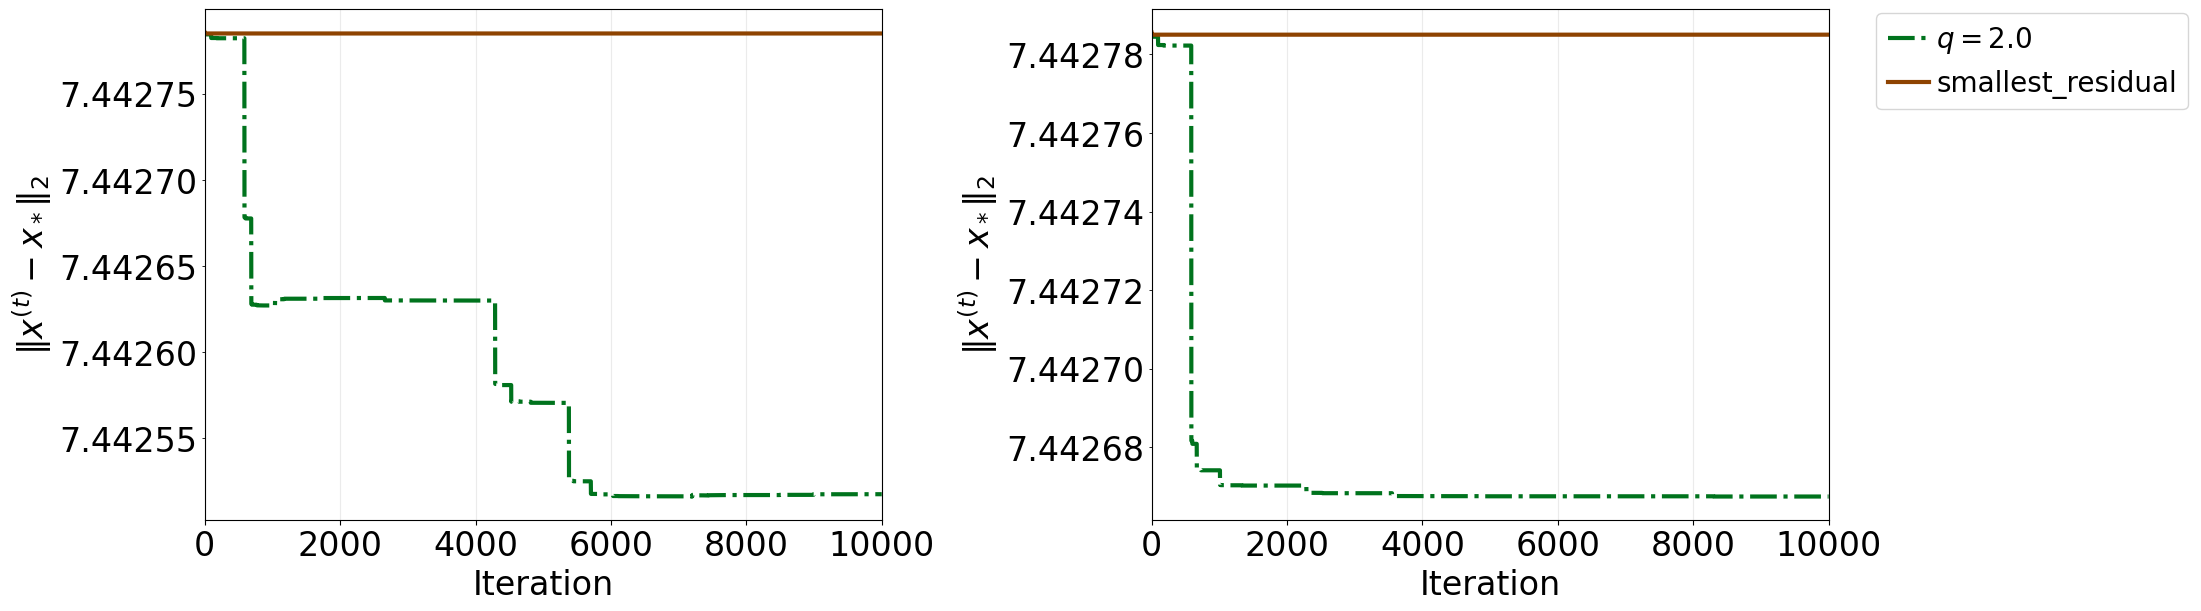

In [16]:
from matplotlib.ticker import FormatStrFormatter

# Separate comparison results keep the preceding experiments and plots unchanged.
smallest_residual_comparison_names = ("inv(q=2)", "smallest_residual")
smallest_residual_results_by_system = {}
for system_name, current_system, existing_results in (
    ("hard", hard_system, hard_results),
    ("easy", easy_system, easy_results),
):
    comparison_results = {
        name: existing_results[name]
        for name in smallest_residual_comparison_names if name in existing_results
    }
    missing_names = [
        name for name in smallest_residual_comparison_names if name not in comparison_results
    ]
    if missing_names:
        comparison_results.update(run_multi_seed_experiment(
            current_system, function_names=missing_names,
            num_runs=NUM_RUNS, seed_start=42, max_iter=MAX_ITER,
            tolerance=TOLERANCE, gamma=1.0, quantile_q=QUANTILE_Q,
            scale_eps=1e-12, histogram_every=histogram_every,
        ))
    smallest_residual_results_by_system[system_name] = comparison_results

smallest_residual_comparison_median_runs = {}
with plt.rc_context({"font.size": FIGURE_FONT_SIZE}):
    smallest_residual_comparison_figure, smallest_residual_comparison_axes = plt.subplots(
        1, 2, figsize=(22.0, 6.0), layout="constrained",
    )
    for ax, system_name in zip(smallest_residual_comparison_axes, ("hard", "easy")):
        comparison_results = smallest_residual_results_by_system[system_name]
        selected_runs = {
            name: select_median_run(comparison_results[name], MEDIAN_BY)
            for name in smallest_residual_comparison_names
        }
        smallest_residual_comparison_median_runs[system_name] = selected_runs
        for name, run in selected_runs.items():
            ax.plot(
                run.iterations, np.maximum(run.approximation_error, 1e-16),
                label=FORMULA_LABELS[name], linewidth=LINEWIDTH,
                color=(function_color_map[name] if name == "inv(q=2)" else "#8e4301"),
                linestyle=(function_line_style_map[name] if name == "inv(q=2)" else "-"),
                alpha=(function_alpha_map.get(name) if name == "inv(q=2)" else 1.0),
            )
        ax.set(
            xlabel="Iteration",
            ylabel=r"$\|x^{(t)}-x_*\|_2$", yscale="log",
            xlim=(0, max(1, max(run.total_iterations for run in selected_runs.values()))),
        )
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.5f"))
        ax.yaxis.set_minor_formatter(FormatStrFormatter("%.5f"))
        ax.grid(True, which="major", alpha=0.25)
    # One shared legend outside both panels, at the upper right.
    handles, labels = smallest_residual_comparison_axes[0].get_legend_handles_labels()
    smallest_residual_comparison_legend = smallest_residual_comparison_figure.legend(
        handles, labels, loc="outside right upper",
        fontsize=paired_legend_font_size,
        handlelength=paired_legend_handlelength,
        handletextpad=paired_legend_handletextpad,
    )
    plt.show()
